<center>

# __Bias in the Lab__

<br>

Dr. [Jose Maria Alonso-Moral](https://citius.gal/team/jose-maria-alonso-moral/)

_Centro Singular de Investigación en Tecnoloxías Intelixentes (CiTIUS)_

_Universidade de Santiago de Compostela_

_ETSE-USC, Campus Vida, Santiago de Compostela, Spain_

<br>

Ms. [Carolina Pavez Higueras](https://citius.gal/team/carolina-pavez-higueras/)

_Centro Singular de Investigación en Tecnoloxías Intelixentes (CiTIUS)_

_Universidade de Santiago de Compostela_

_ETSE-USC, Campus Vida, Santiago de Compostela, Spain_

<br>

__24 February 2026__
 
__Explainable and Trustworthy AI__

<br>

![MIA.png](MIA.png)

</center>

# **1. Introduction**

This interactive tutorial includes supplementary material for the first TAI in the Lab hands-on session (I4. "Bias in the Lab") in the Subject **Explainable and Trustworthy AI** (Master in Artificial Intelligence).  The session is leaded by [Jose M. Alonso-Moral](https://citius.gal/team/jose-maria-alonso-moral) and [Carolina Pavez Higueras](https://citius.gal/team/carolina-pavez-higueras/) at USC, [Samuel Suárez Marcote](https://pdi.udc.es/es/File/Pdi/UA4VL![imagen.png](attachment:imagen.png)) at UDC, and [David Nicholas Olivieri Cecchi](https://www.uvigo.gal/es/universidad/administracion-personal/pdi/david-nicholas-olivieri-cecchi) at UVigo.

Note, the following materials are largely based on documentation and examples available at the [FAT-forensics website](https://fat-forensics.org/getting_started/index.html) and [Aequitas website](https://datasciencepublicpolicy.org/our-work/tools-guides/aequitas/).

# **2. Settings**

This section is aimed for importing files, installing software and loading the required Python libraries.

In [1]:
## this code is developed by Jose Maria Alonso-Moral

import os

# FAT-forenscics
os.system("pip install fat-forensics --quiet")

0

In [2]:
## this code is developed by Jose Maria Alonso-Moral

import matplotlib.pyplot as plt
import numpy as np
import fatf
import fatf.utils.data.datasets as fatf_datasets
import fatf.utils.data.tools as fatf_data_tools
import fatf.utils.data.density as fatf_density
import fatf.utils.models as fatf_models
import fatf.utils.metrics.tools as fatf_metrics_tools
import fatf.utils.metrics.metrics as fatf_metrics
import fatf.utils.metrics.subgroup_metrics as fatf_smt
import fatf.accountability.models.measures as fatf_accountability_models
import fatf.accountability.data.measures as fatf_accountability_data
import fatf.accountability.data.measures as fatf_dam

26-Mar-03 17:15:15 fatf.utils.array.tools INFO     Using numpy's numpy.lib.recfunctions.structured_to_unstructured as fatf.utils.array.tools.structured_to_unstructured and fatf.utils.array.tools.structured_to_unstructured_row.


# **3. Measuring Robustness of a Data Set: Sampling Bias**

In the following we show how robustness of a dataset can be analyzed -from the perspecive of accountability- using the [FAT-forensics library](https://fat-forensics.org/). For this purpose we use data grouping for evaluation of possible sampling bias. This can help us to determine whether defined sub-populations are well represented, or not, in a data set.

We will work with the well-known [IRIS dataset](https://archive.ics.uci.edu/ml/datasets/Iris/). This dataset contains 3 classes of 50 instances each, where each class refers to a type of iris plant. One class is linearly separable from the other 2; the latter are NOT linearly separable from each other. This dataset was created by R.A. Fisher in 1988. The reference paper is a classic in the field and is cited frequently to this day. It was also presented in: R.A. Fisher, The use of multiple measurements in taxonomic problems, Annual Eugenics, 7, Part II, 179-188 (1936).

In [3]:
# Load data
iris_data_dict = fatf_datasets.load_iris()
iris_X = iris_data_dict['data']
iris_y = iris_data_dict['target'].astype(int)
iris_feature_names = iris_data_dict['feature_names']
iris_class_names = iris_data_dict['target_names']

['sepal length (cm)' 'sepal width (cm)' 'petal length (cm)'
 'petal width (cm)']


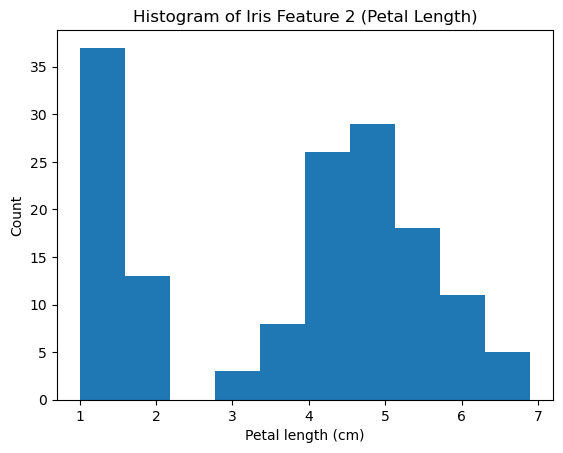

In [4]:
print(iris_feature_names)

# Select feature 2 (third feature)
feature_values = iris_X[:, 2]

# Create histogram
plt.figure()
plt.hist(feature_values, bins=10)
plt.xlabel("Petal length (cm)")
plt.ylabel("Count")
plt.title("Histogram of Iris Feature 2 (Petal Length)")
plt.show()

We start by grouping data using the third feature of the data set. Let us assume that for some, unknown, reason there are two important split values on this feature: 2.5 and 4.75: 

In [5]:
# Select a feature for which the Sampling Bias be measured
selected_feature_index = 2
selected_feature_name = iris_feature_names[selected_feature_index]

# Define grouping on the selected feature
selected_feature_groups = [2.5, 4.75]

We use the function [fatf.utils.data.tools.group_by_column](https://fat-forensics.org/generated/fatf.utils.data.tools.group_by_column.html#fatf.utils.data.tools.group_by_column) for grouping the dataset accordingly:

In [6]:
selected_feature_grouping = fatf_data_tools.group_by_column(
    iris_X,
    selected_feature_index,
    groupings=selected_feature_groups)
selected_feature_grouping[1]

['x <= 2.5', '2.5 < x <= 4.75', '4.75 < x']

Now, we can inspect the resulting groupings and see whether we have a comparable number of data points in each of them:

In [7]:
print(len(selected_feature_grouping[0][0]))
print(len(selected_feature_grouping[0][1]))
print(len(selected_feature_grouping[0][2]))

50
45
55


The number of data points for all the sub-populations seems to be (roughly) equally distributed. The only pair of sub-populations which may indicate a sampling bias is the second and the third one: 2.5 < petal length (cm) <= 4.75 and 4.75 < petal length (cm). For completeness, let us consider the [fatf.accountability.data.measures.sampling_bias_grid_check](https://fat-forensics.org/generated/fatf.accountability.data.measures.sampling_bias_grid_check.html#fatf.accountability.data.measures.sampling_bias_grid_check) function:

In [8]:
counts_per_grouping = [len(i) for i in selected_feature_grouping[0]]
print(counts_per_grouping)
fatf_accountability_data.sampling_bias_grid_check(counts_per_grouping)

[50, 45, 55]


array([[False, False, False],
       [False, False,  True],
       [False,  True, False]])

As expected, the only pair of sub-populations violating sampling bias criterion with the default threshold of 0.8 are sub-populations with indices 1 and 2 making them: 2.5 < petal length (cm) <= 4.75 and 4.75 < petal length (cm)

The same result can be achieved without doing the data grouping manually. To this end, you may use the [fatf.accountability.data.measures.sampling_bias function](https://fat-forensics.org/generated/fatf.accountability.data.measures.sampling_bias.html#fatf.accountability.data.measures.sampling_bias), which internaly groups the data based on the specified feature index. Let's print the resulting counts in a fancier way too.

In [9]:
# Get counts, weights and names of the specified grouping
grp_counts, grp_weights, grp_names = fatf_dam.sampling_bias(iris_X, selected_feature_index, selected_feature_groups)
# Print out counts per group
print('The counts for groups defined on "{}" feature (index {}) are:'
      ''.format(selected_feature_name, selected_feature_index))
for g_name, g_count in zip(grp_names, grp_counts):
    is_are = 'is' if g_count == 1 else 'are'
    print('    * For the population split *{}* there {}: '
          '{} data points.'.format(g_name, is_are, g_count))

The counts for groups defined on "petal length (cm)" feature (index 2) are:
    * For the population split *x <= 2.5* there are: 50 data points.
    * For the population split *2.5 < x <= 4.75* there are: 45 data points.
    * For the population split *4.75 < x* there are: 55 data points.


And repeat the analysis to check that results are analogous:

In [10]:
# Get the disparity grid
bias_grid = fatf_dam.sampling_bias_grid_check(grp_counts)
print(bias_grid)

# Print out disparity per every grouping pair
print('\nThe Sampling Bias for *{}* feature (index {}) grouping is:'
      ''.format(selected_feature_name, selected_feature_index))
for grouping_i, grouping_name_i in enumerate(grp_names):
    j_offset = grouping_i + 1
    for grouping_j, grouping_name_j in enumerate(grp_names[j_offset:]):
        grouping_j += j_offset
        is_not = '' if bias_grid[grouping_i, grouping_j] else ' NO'

        print('    * For "{}" and "{}" groupings there is{} Sampling Bias.'
              ''.format(grouping_name_i, grouping_name_j, is_not))

[[False False False]
 [False False  True]
 [False  True False]]

The Sampling Bias for *petal length (cm)* feature (index 2) grouping is:
    * For "x <= 2.5" and "2.5 < x <= 4.75" groupings there is NO Sampling Bias.
    * For "x <= 2.5" and "4.75 < x" groupings there is NO Sampling Bias.
    * For "2.5 < x <= 4.75" and "4.75 < x" groupings there is Sampling Bias.


### **Exercise 1**
The function [fatf_dam.sampling_bias_grid_check](https://fat-forensics.org/generated/fatf.accountability.data.measures.sampling_bias_grid_check.html#fatf.accountability.data.measures.sampling_bias_grid_check) uses a default threshold of 0.8 to compute the pairwise sampling bias. Let us now modify this threshold to use a value of 0.5, and check the resulting output.
* Do you observe any change in reported results? How? Why?
* What does the given threshold account for? (you might want to check the corresponding API documentation)
* Given the defined group counts, what would be the minimal threshold that would cause the function to inform of existence of sampling bias?


In [11]:
bias_grid = fatf_dam.sampling_bias_grid_check(grp_counts, 0.8)
print(bias_grid)

# Print out disparity per every grouping pair
print('\nThe Sampling Bias for *{}* feature (index {}) grouping is:'
      ''.format(selected_feature_name, selected_feature_index))
for grouping_i, grouping_name_i in enumerate(grp_names):
    j_offset = grouping_i + 1
    for grouping_j, grouping_name_j in enumerate(grp_names[j_offset:]):
        grouping_j += j_offset
        is_not = '' if bias_grid[grouping_i, grouping_j] else ' NO'

        print('    * For "{}" and "{}" groupings there is{} Sampling Bias.'
              ''.format(grouping_name_i, grouping_name_j, is_not))

[[False False False]
 [False False  True]
 [False  True False]]

The Sampling Bias for *petal length (cm)* feature (index 2) grouping is:
    * For "x <= 2.5" and "2.5 < x <= 4.75" groupings there is NO Sampling Bias.
    * For "x <= 2.5" and "4.75 < x" groupings there is NO Sampling Bias.
    * For "2.5 < x <= 4.75" and "4.75 < x" groupings there is Sampling Bias.


In [12]:
bias_grid = fatf_dam.sampling_bias_grid_check(grp_counts, 0.5)
print(bias_grid)

# Print out disparity per every grouping pair
print('\nThe Sampling Bias for *{}* feature (index {}) grouping is:'
      ''.format(selected_feature_name, selected_feature_index))
for grouping_i, grouping_name_i in enumerate(grp_names):
    j_offset = grouping_i + 1
    for grouping_j, grouping_name_j in enumerate(grp_names[j_offset:]):
        grouping_j += j_offset
        is_not = '' if bias_grid[grouping_i, grouping_j] else ' NO'

        print('    * For "{}" and "{}" groupings there is{} Sampling Bias.'
              ''.format(grouping_name_i, grouping_name_j, is_not))

[[False False False]
 [False False False]
 [False False False]]

The Sampling Bias for *petal length (cm)* feature (index 2) grouping is:
    * For "x <= 2.5" and "2.5 < x <= 4.75" groupings there is NO Sampling Bias.
    * For "x <= 2.5" and "4.75 < x" groupings there is NO Sampling Bias.
    * For "2.5 < x <= 4.75" and "4.75 < x" groupings there is NO Sampling Bias.


### **Exercise 1 Answer**
**Do you observe any change in reported results? How? Why?**

`Yes,the result changes when the threshold changes from 0.8 to 0.5.`
`With thresold = 0.8 the Bias grid is :`

|                      | x ≤ 2.5 | 2.5 < x ≤ 4.75 | 4.75 < x |
|----------------------|---------|----------------|----------|
| **x ≤ 2.5**          | False   | False          | False    |
| **2.5 < x ≤ 4.75**   | False   | False          | **True** |  <= Bias Here
| **4.75 < x**         | False   | **True**       | False    |  <= Bias Here

`The matrix highlights (**True** value) a  Sample Bias between groups ("2.5 < x <= 4.75") and groups (4.75 < x") `
 `While with threshold = 0.5 the grid is :`
|                      | x ≤ 2.5 | 2.5 < x ≤ 4.75 | 4.75 < x |
|----------------------|---------|----------------|----------|
| **x ≤ 2.5**          | False   | False          | False    |
| **2.5 < x ≤ 4.75**   | False   | False          | False    |  
| **4.75 < x**         | False   | False          | False    |  

`No sampling bias anywhere.`

`The function checks if the  relative imbalance between every pair of groups exceeds a given threshold.`
`The threshold defines how much imbalance between two groups is tolerated before it is flagged as bias.`
`With a higher threshold (0.8)   the condition is stricter`
`With a lower threshold  (0.5)   more imbalance is tolerated`

**What does the given threshold account for? (you might want to check the corresponding API documentation)**

`The threshold defines the minimum acceptable ratio between two group sizes, If the ratio is below a fixed threshold then a bias is reported.`

`In the first case (thresold = 0.8) the smaller group must be at least 80% the size of the larger group otherwise bias is flagged.`

`In the second case (thresold = 0.5) the smaller group only needs to be 50% the size of the larger group which implies that more imbalance between groups is allowed.`

**Given the defined group counts, what would be the minimal threshold that would cause the function to inform of existence of sampling bias?**


The function [**sampling_bias_grid_check**](https://fat-forensics.org/generated/fatf.accountability.data.measures.sampling_bias_grid_check.html) compares pairs of groups and checks the ratio between their sizes.
If this ratio is below the threshold, the function reports sampling bias.

Given Group counts is : [50,45,55]  
We have 3 groups  
Groups:  
G1​=50  
G2=45  
G3=55  

We compare all group counts:  
G1 vs G2 ======>>> calculate min(G1,G2)/max(G1,G2) = 45/50 = 0.9  
G1 vs G3 ======>>> calculate min(G1,G3)/max(G1,G3) = 50/55 = 0.909...  
G2 vs G3 ======>>> calculate min(G2,G3)/max(G2,G3) = 45/55 = 0.818..  <<=== smnallest ratio  

Sampling bias is detected when ratio < threshold   
The smallest ratio we computed was: 0.818  
so bias will be detected when: threshold>0.818  






# **4. Measuring Robustness of a Predictive Model: Systematic Performance Bias**

We now illustrate how to measure Systematic Performance Bias of a model based on a selected predictive performance metric (accuracy in this example) using again the [FAT-fonrensics library](https://fat-forensics.org/getting_started/index.html).

To this end we will train a model using the same IRIS data set as in the previous section. We use a k-Nearest Neighbours (kNN) classifier directly using the whole dataset.

In [13]:
clf = fatf_models.KNN()
clf.fit(iris_X, iris_y)

# Get predictions of the model for performance evaluation (using also the whole dataset)
iris_pred = clf.predict(iris_X)
print(iris_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1
 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 1 2 2 2 2
 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Let us get the confusion matrices for each of the defined sub-populations (we use those defined in the previous section):

In [14]:
grouping_cm = fatf_metrics_tools.confusion_matrix_per_subgroup_indexed(
    selected_feature_grouping[0],
    iris_y,
    iris_pred,
    labels=np.unique(iris_y).tolist())

/opt/conda/lib/python3.11/site-packages/fatf/utils/metrics/tools.py:207: UserWarning: Some of the given labels are not present in either of the input arrays: {1, 2}.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/fatf/utils/metrics/tools.py:207: UserWarning: Some of the given labels are not present in either of the input arrays: {0}.
  warnings.warn(


Note the above function call generates 2 warnings:

* UserWarning: Some of the given labels are not present in either of the input arrays: {1, 2}.
* UserWarning: Some of the given labels are not present in either of the input arrays: {0}.

These warnings are because for some of the sub-populations the ground truth (target) and the prediction vectors may only hold a single label, therefore the confusion matrix calculator is not aware of the rest and has to resort to using the labels specified in the labels parameter. 

This happens as the selected feature – petal length (cm) – is a very good predictor of the first class. Printing the unique target and prediction values of the first sub-population shows exactly what is happening:

In [15]:
print('First subgroup')
print('Targets: ', iris_y[selected_feature_grouping[0][0]])
print('Unique targets: ', np.unique(iris_y[selected_feature_grouping[0][0]]))
print('Unique predictions: ', np.unique(iris_pred[selected_feature_grouping[0][0]]))
print('Confusion matrix: ')
print(grouping_cm[0])

First subgroup
Targets:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
Unique targets:  [0]
Unique predictions:  [0]
Confusion matrix: 
[[50  0  0]
 [ 0  0  0]
 [ 0  0  0]]


Let us now show the resulting confusion matrices for the other two groups:

In [16]:
print('Second subgroup')
#print(np.unique(iris_y[selected_feature_grouping[0][1]]))
#print(np.unique(iris_pred[selected_feature_grouping[0][1]]))
print('Confusion matrix: ')
print(grouping_cm[1])

print('Third subgroup')
#print(np.unique(iris_y[selected_feature_grouping[0][2]]))
#print(np.unique(iris_pred[selected_feature_grouping[0][2]]))
print('Confusion matrix: ')
print(grouping_cm[2])

Second subgroup
Confusion matrix: 
[[ 0  0  0]
 [ 0 44  1]
 [ 0  0  0]]
Third subgroup
Confusion matrix: 
[[ 0  0  0]
 [ 0  3  2]
 [ 0  3 47]]


With confusion matrices for every grouping we can calculate the corresponding performance metrics. Let us look carefully at accuracy:

In [17]:
group_0_acc = fatf_metrics.accuracy(grouping_cm[0])
print(group_0_acc)
group_1_acc = fatf_metrics.accuracy(grouping_cm[1])
print(group_1_acc)
group_2_acc = fatf_metrics.accuracy(grouping_cm[2])
print(group_2_acc)

1.0
0.9777777777777777
0.9090909090909091


The accuracy seems to be comparable across sub-populations. Apparently none of the sub-populations defined on the petal length feature suffers from a performance bias as measured by accuracy. For completeness, let us test for the systematic performance bias with the [fatf.accountability.models.measures.systematic_performance_bias_grid](https://fat-forensics.org/generated/fatf.accountability.models.measures.systematic_performance_bias_grid.html#fatf.accountability.models.measures.systematic_performance_bias_grid) function:

In [18]:
fatf_accountability_models.systematic_performance_bias_grid([group_0_acc, group_1_acc, group_2_acc])

array([[False, False, False],
       [False, False, False],
       [False, False, False]])

### **Exercise 2**
Similar to the previous [fatf_dam.sampling_bias_grid_check](https://fat-forensics.org/generated/fatf.accountability.data.measures.sampling_bias_grid_check.html#fatf.accountability.data.measures.sampling_bias_grid_check), [fatf_accountability_models.systematic_performance_bias_grid](https://fat-forensics.org/generated/fatf.accountability.models.measures.systematic_performance_bias_grid.html#fatf.accountability.models.measures.systematic_performance_bias_grid), you can use certain thresholds for this evaluation and answer the following questions:
* What is the default threshold applied in this case? 
* Is the criterion for bias evaluation somehow different to the case of sampling bias seen in the previous section?
* Experiment with the code below and find a threshold that would result in the model to be qualified as containing systematic performance bias. Which groups would be involved? 

In [19]:
fatf_accountability_models.systematic_performance_bias_grid([group_0_acc, group_1_acc, group_2_acc], 0.9)

array([[False, False,  True],
       [False, False, False],
       [ True, False, False]])

In [20]:
fatf_accountability_models.systematic_performance_bias_grid([group_0_acc, group_1_acc, group_2_acc], 0.91)

array([[False, False,  True],
       [False, False, False],
       [ True, False, False]])

In [21]:
fatf_accountability_models.systematic_performance_bias_grid([group_0_acc, group_1_acc, group_2_acc], 0.94)

array([[False, False,  True],
       [False, False,  True],
       [ True,  True, False]])

In [22]:
fatf_accountability_models.systematic_performance_bias_grid([group_0_acc, group_1_acc, group_2_acc], 0.98)

array([[False,  True,  True],
       [ True, False,  True],
       [ True,  True, False]])

### **Exercise 2 Answers**

**What is the default threshold applied in this case?**

`The default threshold is 0.8.`

**Is the criterion for bias evaluation somehow different to the case of sampling bias seen in the previous section?**

`Yes. Sampling bias compares group representation counts, meanwhile performance bias compares subgroup performance metrics, like accuracy.`

**Experiment with the code below and find a threshold that would result in the model to be qualified as containing systematic performance bias. Which groups would be involved?**

`First, we compute the pairwise ratios of accuracy between each group. The accuracies are: group 0: 1.0, group 1: 0.9778, and group 2: 0.9091. The ratio for each pair is calculated as the smaller accuracy divided by the larger one. For group 0 and group 1, the ratio is 0.9778 / 1.0 = 0.9778. For group 0 and group 2, the ratio is 0.9091 / 1.0 = 0.9091. For group 1 and group 2, the ratio is 0.9091 / 0.9778 ≈ 0.9300.`

`The systematic performance bias function flags a pair if the ratio is below the threshold. With a threshold of 0.90, no ratios are below 0.90, so no bias should be detected, but it does, maybe for a rounding error. With a threshold of 0.91, the ratio between group 0 and group 2 (0.9091) is below the threshold, so bias is detected only between these two groups. With a threshold of 0.94, both group 0 vs group 2 (0.9091) and group 1 vs group 2 (0.9300) are below the threshold, so bias is detected between group 2 and the other two groups. With a threshold of 0.98, all ratios are below the threshold, so bias is detected between all pairs.`

`The model first becomes qualified as containing systematic performance bias at a threshold of 0.91, involving group 0 and group 2. As the threshold increases, more pairs are flagged: at 0.94, bias involves group 2 against groups 0 and 1, and at 0.98, all groups are involved. The bias is primarily driven by the lower performance of group 2 (accuracy 0.9091) compared to the other groups.`

Execute now the code below, which makes use of the function [fatf.utils.metrics.subgroup_metrics.performance_per_subgroup](https://fat-forensics.org/generated/fatf.utils.metrics.subgroup_metrics.performance_per_subgroup.html#fatf.utils.metrics.subgroup_metrics.performance_per_subgroup) for similar purposes. In this case we train the classifier using less data, and use a different feature and splitting criterion.

In [23]:
# Optional: fit using less data, resulting in a less accurate classifier
clf2 = fatf_models.KNN()
training_set_X = iris_X[:80,:]
training_set_y = iris_y[:80]
#print(training_set_X)
clf2.fit(training_set_X, training_set_y)
# Get predictions of the model for performance evaluation (using also the whole dataset)
iris_pred = clf2.predict(iris_X)

# Select a predictive performance metric
#predictive_performance_metric = 'accuracy'
predictive_performance_metric = 'positive predictive value' # Notice a class index needs to be selected using "label_index" property
#predictive_performance_metric = 'false negative rate' # Notice a class index needs to be selected using "label_index" property

# Select a feature for which the difference in performance should be measured
selected_feature_index = 1 # before was 2, in FAT-forensics example was 1
selected_feature_name = iris_feature_names[selected_feature_index]

# Define grouping on the selected feature
selected_feature_groups = [3] # before was [2.5, 4.75], , in FAT-forensics example was [3]

selected_feature_grouping = fatf_data_tools.group_by_column(
    iris_X,
    selected_feature_index,
    groupings=selected_feature_groups)
print('Grouping using variable', iris_feature_names[selected_feature_index], ' as ', selected_feature_grouping[1])

grouping_cm = fatf_metrics_tools.confusion_matrix_per_subgroup_indexed(
    selected_feature_grouping[0],
    iris_y,
    iris_pred,
    labels=np.unique(iris_y).tolist())

print('Resulting confusion matrices:')
for i in range(len(grouping_cm)):
    print('Confusion matrix', i, ':')
    print(grouping_cm[i])

# Compute performance per group in the feature
population_metrics, population_names = fatf_smt.performance_per_subgroup(
    iris_X,
    iris_y,
    iris_pred,
    selected_feature_index,
    groupings=selected_feature_groups,
    metric=predictive_performance_metric, 
    label_index = 2)

#print(population_metrics)

# Print out performance per grouping
print('The *{}* for groups defined on "{}" feature (feature index '
      '{}):'.format(predictive_performance_metric, selected_feature_name,
                    selected_feature_index))
for p_name, p_metric in zip(population_names, population_metrics):
    print('    * For the population split *{}* the {} is: '
          '{:.2f}.'.format(p_name, predictive_performance_metric, p_metric))

# Evaluate Systematic Performance Bias
bias_grid = fatf_accountability_models.systematic_performance_bias_grid(population_metrics)
print('Systematic performance grid check:')
print(bias_grid)

# Print out Systematic Performance Bias for each grouping pair
print('\nThe *{}-based* Systematic Performance Bias for *{}* feature (index '
      '{}) grouping is:'.format(predictive_performance_metric,
                                selected_feature_name, selected_feature_index))
                                
for grouping_i, grouping_name_i in enumerate(population_names):
    j_offset = grouping_i + 1
    for grouping_j, grouping_name_j in enumerate(population_names[j_offset:]):
        grouping_j += j_offset
        is_not = '' if bias_grid[grouping_i, grouping_j] else ' NO'

        print('    * For "{}" and "{}" groupings there is{} Systematic '
              'Performance Bias.'.format(grouping_name_i, grouping_name_j,
                                         is_not))

Grouping using variable sepal width (cm)  as  ['x <= 3', '3 < x']
Resulting confusion matrices:
Confusion matrix 0 :
[[ 8  0  0]
 [ 0 42 33]
 [ 0  0  0]]
Confusion matrix 1 :
[[42  0  0]
 [ 0  8 17]
 [ 0  0  0]]
The *positive predictive value* for groups defined on "sepal width (cm)" feature (feature index 1):
    * For the population split *x <= 3* the positive predictive value is: 0.00.
    * For the population split *3 < x* the positive predictive value is: 0.00.
Systematic performance grid check:
[[False False]
 [False False]]

The *positive predictive value-based* Systematic Performance Bias for *sepal width (cm)* feature (index 1) grouping is:
    * For "x <= 3" and "3 < x" groupings there is NO Systematic Performance Bias.


/opt/conda/lib/python3.11/site-packages/fatf/accountability/models/measures.py:117: RuntimeWarning: invalid value encountered in divide
  proportions = metrics_array[np.newaxis, :] / metrics_array[:, np.newaxis]


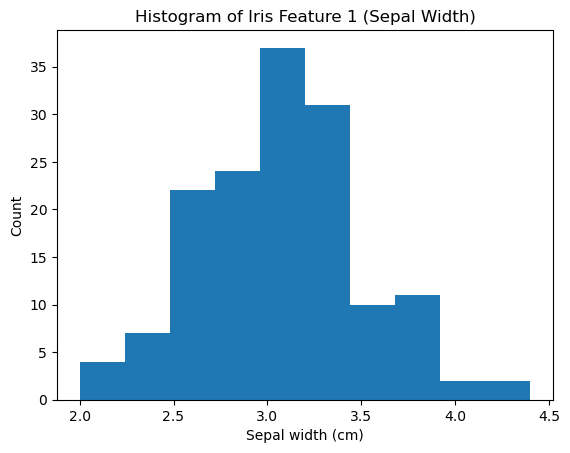

In [24]:
# Select feature 1 (third feature)
feature_values = iris_X[:, 1]

# Create histogram
plt.figure()
plt.hist(feature_values, bins=10)
plt.xlabel("Sepal width (cm)")
plt.ylabel("Count")
plt.title("Histogram of Iris Feature 1 (Sepal Width)")
plt.show()

### **Exercise 3**
* Which conclusions can you draw now?
* Execute the previous code again, but now select "Positive Predictive Value (PPV)" as performance metric. Do you observe any difference?
* What does "PPV" account for?
* Which is the role of the parameter "label index" in the [performance_per_subgroup](https://fat-forensics.org/generated/fatf.utils.metrics.subgroup_metrics.performance_per_subgroup.html#fatf.utils.metrics.subgroup_metrics.performance_per_subgroup) function? Does it make a difference changing it ("0", "1", or "2") if using "accuracy"? Does it make a difference changing it in case of using "PPV"? Why?

### **Exercise 3 Answers**

**Which conclusions can you draw now?**

`The analysis shows that when the classifier is trained on less data, its performance differs noticeably between sub-populations defined by sepal width. The subgroup with smaller sepal width (x <= 3) has lower accuracy (0.60) compared to the subgroup with larger sepal width (x > 3) which has higher accuracy (0.75). This indicates that the model’s performance is not uniform across these groups, revealing the presence of systematic performance bias. The bias grid confirms that there is accuracy-based systematic performance bias between the two sub-populations. This demonstrates that reducing training data can increase disparities in model performance across different subgroups.`

**Execute the previous code again, but now select "Positive Predictive Value (PPV)" as performance metric. Do you observe any difference?**

`Yes, when using Positive Predictive Value (PPV) as the performance metric, both sub-populations defined by sepal width have a PPV of 0.00. As a result, the systematic performance bias grid shows no bias between the groups. This differs from the accuracy-based analysis, where clear differences were observed between the two sub-populations. The reason for this is that PPV measures the proportion of correct positive predictions for a specific class, and in this case the chosen class has no correct positive predictions in either group, which produces a PPV of zero for both. Consequently, the bias check based on PPV does not detect any disparity, even though accuracy revealed differences. The runtime warning indicates a division by zero occurred internally when calculating the PPV ratios, which is consistent with both groups having zero positive predictive value.`

**What does "PPV" account for?**

`It is Positive Predicitve Values: PPV = TP / (TP + FP). It measures reliability of positive predictions. In other words, it tells you, for a given class, how many of the items the model labeled as that class are actually correct. It is a class-specific precision metric and does not consider other classes when computing the value.`

**Which is the role of the parameter "label index" in the performance_per_subgroup function? Does it make a difference changing it ("0", "1", or "2") if using "accuracy"? Does it make a difference changing it in case of using "PPV"? Why?**

`The label_index parameter specifies which class the metric should be calculated for when using class-specific metrics, such as PPV or false negative rate. It does not affect metrics that are global over all classes, like accuracy, because accuracy considers all correct predictions regardless of class. Therefore, changing label_index when computing accuracy has no effect. However, for PPV, changing label_index does make a difference because PPV is calculated separately for the chosen class. Each class can have a very different PPV depending on the model’s predictions, so selecting a different label_index changes which class’s PPV is being reported.`

# **5. Measuring Robustness of a Prediction: Data Density**

Below, we show how to use data density estimation with the [FAT-fonrensics library](https://fat-forensics.org/getting_started/index.html) to “measure” to what extent a prediction should be trusted. We will keep on using the IRIS dataset and the kNN model as in the previous sections. 

First, we visualise the dataset based on two (arbitrarily chosen) features:

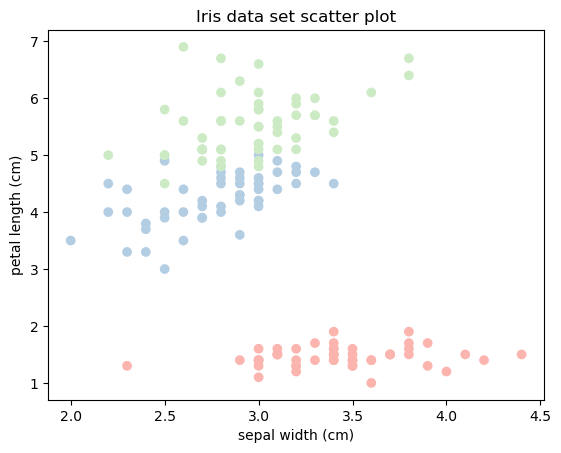

In [25]:
# Prepare a colourmap
cmap = np.array([
    plt.get_cmap('Pastel1').colors[0],
    plt.get_cmap('Pastel1').colors[1],
    plt.get_cmap('Pastel1').colors[2]
])
# Choose 2 features
chosen_features_index = [1, 2]
chosen_features_name = iris_feature_names[chosen_features_index]

# Get a subset of the data set with these two features
iris_X_chosen_features = iris_X[:, chosen_features_index]

# Plot the dataset using the 2 selected features
plt.scatter(
    iris_X_chosen_features[:, 0], iris_X_chosen_features[:, 1], c=cmap[iris_y])
plt.title('Iris data set scatter plot')
plt.xlabel(chosen_features_name[0])
plt.ylabel(chosen_features_name[1])
plt.show()

Now, we train a predictive model on the whole dataset using these two selected features. We will use this model to evaluate the quality and robustness of its predictions.

In [26]:
# Train a model
clf = fatf_models.KNN()
clf.fit(iris_X_chosen_features, iris_y)

We choose now one data point in a sparse region and another one in a dense region:

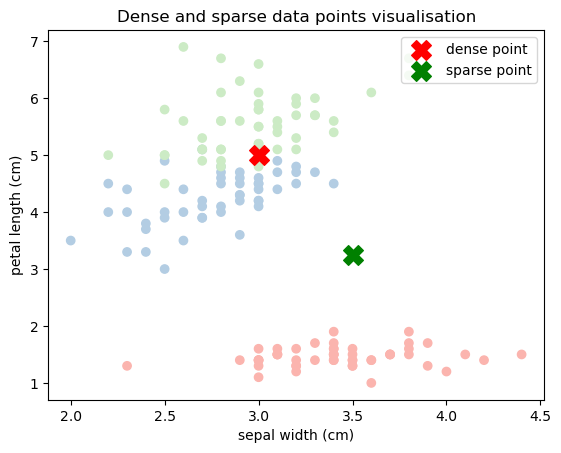

In [27]:
# Create two data points: one in a dense region and one in a sparse region
point_dense = np.array([[3.0, 5.0]])
point_sparse = np.array([[3.5, 3.25]])

# Plot the dense and sparse data points
plt.scatter(
    iris_X_chosen_features[:, 0], iris_X_chosen_features[:, 1], c=cmap[iris_y])
plt.scatter(
    point_dense[:, 0],
    point_dense[:, 1],
    c='r',
    s=200,
    marker='X',
    label='dense point')
plt.scatter(
    point_sparse[:, 0],
    point_sparse[:, 1],
    c='g',
    s=200,
    marker='X',
    label='sparse point')
plt.title('Dense and sparse data points visualisation')
plt.xlabel(chosen_features_name[0])
plt.ylabel(chosen_features_name[1])
plt.legend(loc='upper right')
plt.show()

Now, let us get the predictions for the two data points selected above.

The **dense** data point is of class: virginica (2).
The **sparse** data point is of class: versicolor (1).


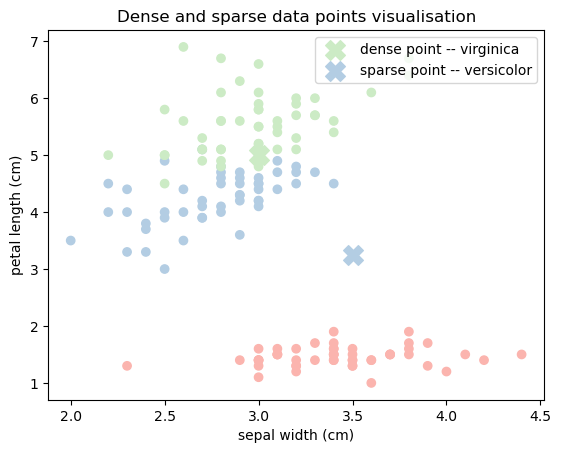

In [28]:
# Predict the two data points
point_dense_prediction = clf.predict(point_dense)[0]
point_sparse_prediction = clf.predict(point_sparse)[0]

# Print out the predictions...
print('The **dense** data point is of class: {} ({}).'.format(
    iris_class_names[point_dense_prediction], point_dense_prediction))
print('The **sparse** data point is of class: {} ({}).'.format(
    iris_class_names[point_sparse_prediction], point_sparse_prediction))

# ...and plot them with the class assignment
plt.scatter(
    iris_X_chosen_features[:, 0], iris_X_chosen_features[:, 1], c=cmap[iris_y])
plt.scatter(
    point_dense[:, 0],
    point_dense[:, 1],
    c=cmap[[int(point_dense_prediction)]],
    s=200,
    marker='X',
    label='dense point -- {}'.format(iris_class_names[point_dense_prediction]))
plt.scatter(
    point_sparse[:, 0],
    point_sparse[:, 1],
    c=cmap[[int(point_sparse_prediction)]],
    s=200,
    marker='X',
    label='sparse point -- {}'.format(
        iris_class_names[point_sparse_prediction]))
plt.title('Dense and sparse data points visualisation')
plt.xlabel(chosen_features_name[0])
plt.ylabel(chosen_features_name[1])
plt.legend(loc='upper right')
plt.show()

Now that we know where these two data points are located and what class is assigned to each of them by the classifier, we can see how a Data Density score can help us evaluate the quality and robustness of the predictions of the model:

In [29]:
# Print the class names for the probability vector
print('(The probability vector is based on the following class ordering: '
      '{}.)\n'.format(iris_class_names))

# Initialise a density estimator
iris_density = fatf_density.DensityCheck(iris_X_chosen_features)

# Get a denisty estimation for the dense point
density_score_dense = iris_density.score_data_point(point_dense[0, :])
# Get the probability predictions for the dense point
probabilities_dense = clf.predict_proba(point_dense)[0]

# Get a denisty estimation for the sparse point
density_score_sparse = iris_density.score_data_point(point_sparse[0, :])
# Get the probability predictions for the sparse point
probabilities_sparse = clf.predict_proba(point_sparse)[0]

print('The prediction probabilities for the sparse data point are: {}, with a '
      'density score of {}.'.format(probabilities_sparse,
                                    density_score_sparse))

print('The prediction probabilities for the dense data point are: {}, with a '
      'density score of {}.'.format(probabilities_dense, density_score_dense))

(The probability vector is based on the following class ordering: ['setosa' 'versicolor' 'virginica'].)

The prediction probabilities for the sparse data point are: [0. 1. 0.], with a density score of 0.9481604611988929.
The prediction probabilities for the dense data point are: [0.         0.33333333 0.66666667], with a density score of 0.10186747546117353.


### **Exercise 4**
**Check the API documentation and explain what the "density score" actually represents.**

`According to the API documentation, the density score measures how densely populated the local region around a data point is within the feature space.`
`A high density score means the point lies in a region where many similar samples exist.`
`A low density score means the point lies in a sparse region, far from many other samples`

**Given the previous results:**
- **Should we trust the model's output classifications?** 

`The reliability of model predictions depends on the density score.`
`For high-density points,the model has seen many similar examples.`
`Predictions are generally more stable and reliable.`
`We can trust these classifications more.`

`For low-density (sparse) points,the model has little nearby training data.`
`These classifications are less reliable.`


**- Is there any difference in this regard between the dense and spare point classifications?**

`Yes.`
`There is an important difference:`
- `The Dense point classifications are more robust, with lower uncertainty and more supported by training data that is the model has seen many similar examples during training in that region of the feature space`.

- `The sparse point classifications are ubnstable,less supported by training data and instable`

# **5. Experimenting with Aequitas**

Below, we show how to use the [Aequitas software](https://dssg.github.io/aequitas/) with the COMPAS dataset. COMPAS produces a risk score that predicts a person's likelihood of commiting a crime in the next two years. The output is a score between 1 and 10 that maps to low, medium or high. For the example here, we collapse this to a binary prediction. A score of 0 indicates a prediction of "low" risk according to COMPAS, while a 1 indicates "high" or "medium" risk.

The aim of this section is helping you understand how numbers in an Aequitas Bias Report are computed (see [https://github.com/dssg/aequitas/blob/master/docs/source/examples/compas_demo.ipynb](https://github.com/dssg/aequitas/blob/master/docs/source/examples/compas_demo.ipynb)).

In [30]:
# AEQUITAS
os.system("pip install aequitas==1.0.0")

0

In [31]:
os.system("pip install numpy==1.24.4")

0

In [32]:
import pandas as pd
import seaborn as sns
from aequitas.audit import Audit
from aequitas.bias import Bias
from aequitas.fairness import Fairness
from aequitas.group import Group
import aequitas.plot as ap

In [33]:
! pwd

/home/jovyan/work/XAI-TAI/D2


We begin with loading the COMPAS dataset.

In [34]:
df = pd.read_csv("./testlib/COMPAS/compas_for_aequitas.csv")
df.head()

,entity_id,score,label_value,race,sex,age_cat
0,1,0.0,0,Other,Male,Greater than 45
1,3,0.0,1,African-American,Male,25 - 45
2,4,0.0,1,African-American,Male,Less than 25
3,5,1.0,0,African-American,Male,Less than 25
4,6,0.0,0,Other,Male,25 - 45


Below, you can see how data are distributed for some protected features (i.e., race, sex, and age). But also the assigned labels for low or high recedivism prediction.

In [35]:
aq_palette = sns.diverging_palette(225, 35, n=2)
sns.set_theme(rc={'figure.figsize':(11.5,6.5)})

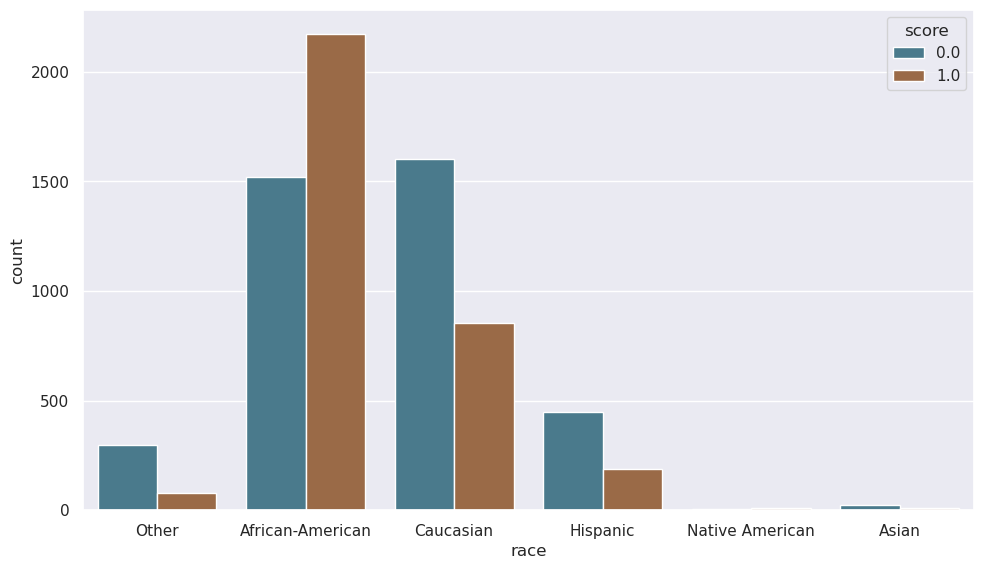

In [36]:
by_race = sns.countplot(x="race", hue="score", data=df[df.race.isin(['African-American', 'Caucasian', 'Asian', 'Native American', 'Hispanic', 'Other'])], palette=aq_palette)

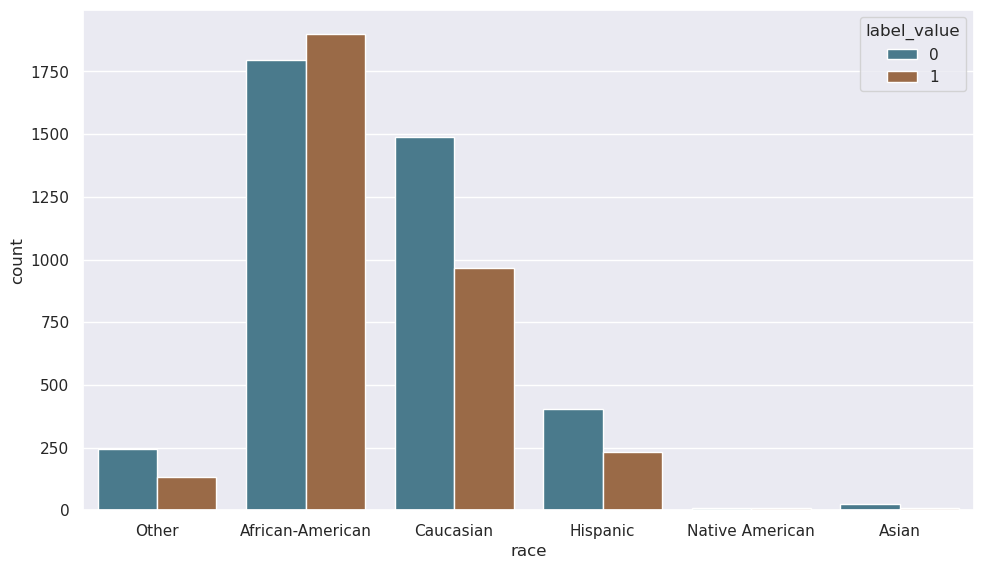

In [37]:
label_by_race = sns.countplot(x="race", hue="label_value", data=df[df.race.isin(['African-American', 'Caucasian', 'Asian', 'Native American', 'Hispanic', 'Other'])], palette=aq_palette)

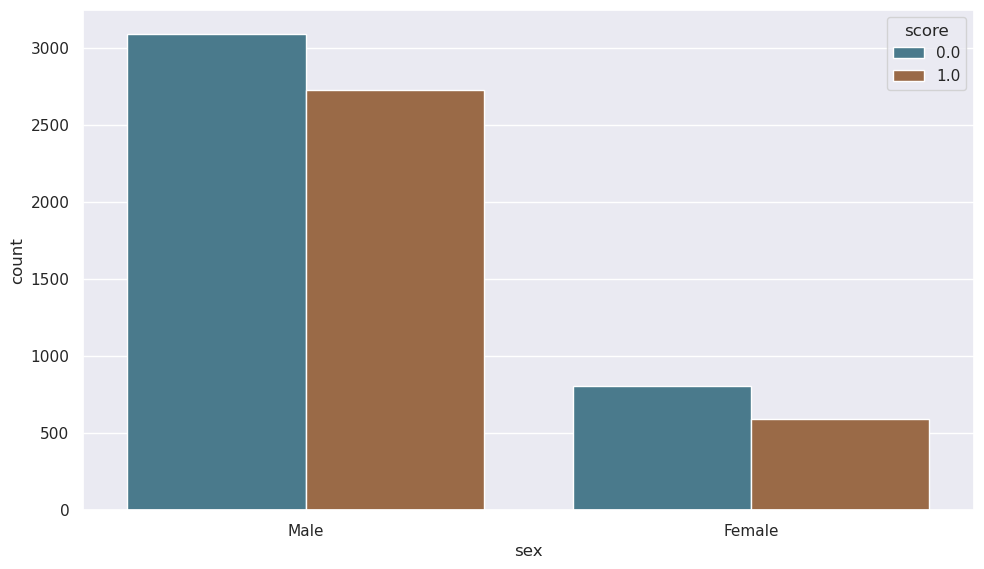

In [38]:
by_sex = sns.countplot(x="sex", hue="score", data=df, palette=aq_palette)

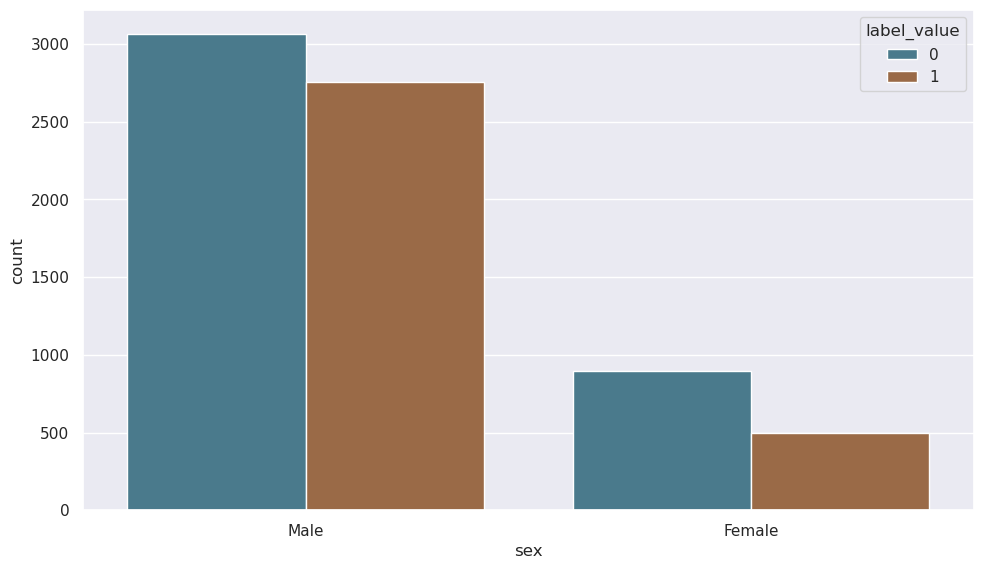

In [39]:
label_by_sex = sns.countplot(x="sex", hue="label_value", data=df, palette=aq_palette)

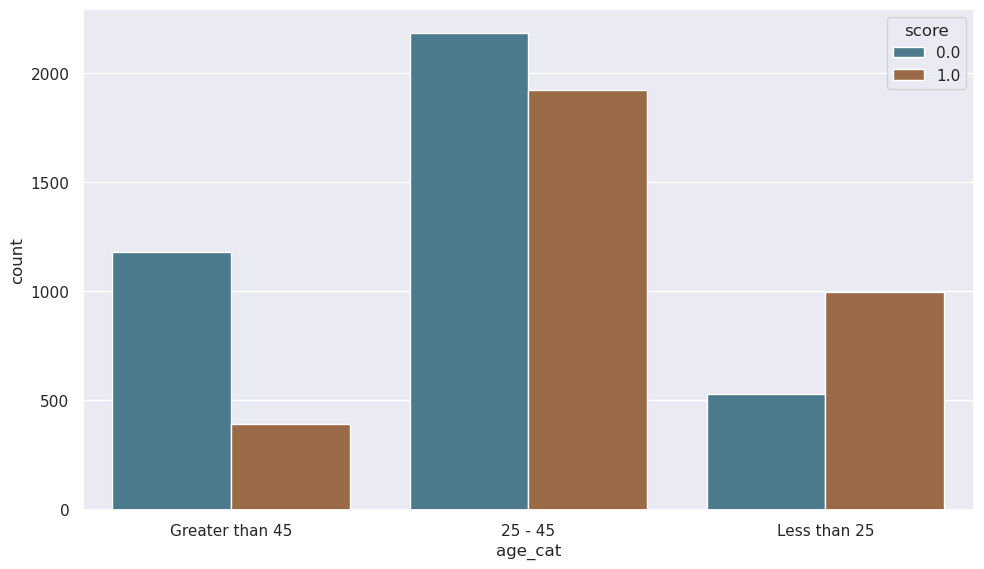

In [40]:
by_age = sns.countplot(x="age_cat", hue="score", data=df, palette=aq_palette)

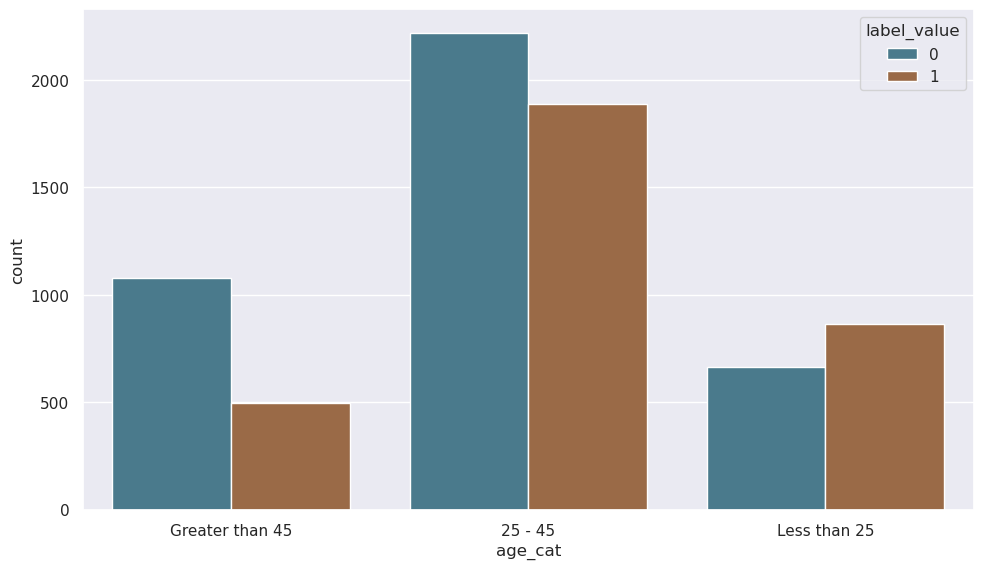

In [41]:
label_by_age = sns.countplot(x="age_cat", hue="label_value", data=df, palette=aq_palette)

Now, we are to use Aequitas in three steps:

* Defining Groups
* Calculating Disparities
* Asseerting Fairness

Notice that Aequitas always requires a score column and requires a binary label_value column for supervised metrics, (e.g., False Discovery Rate - FDR, False Positive Rate - FPR, False Omission Rate - FOR, and False Negative Rate - FNR). Preprocessing includes but is not limited to checking for mandatory score and label_value columns as well as at least one column representing attributes specific to the data set. Moreover, Aequitas recognizes entity_id as a reserve column name and will not recognize it as an attribute column.

The following tables provide you with a legend to understand the results below.

#### Group Counts Calculated:

| Count Type | Column Name |
| --- | --- |
| False Positive Count | 'fp' |
| False Negative Count | 'fn' |
| True Negative Count | 'tn' |
| True Positive Count | 'tp' |
| Predicted Positive Count | 'pp' |
| Predicted Negative Count | 'pn' |
| Count of Negative Labels in Group | 'group_label_neg' |
| Count of Positive Labels in Group | 'group_label_pos' |
| Group Size | 'group_size'|
| Total Entities | 'total_entities' |

#### Absolute Metrics Calculated:

| Metric | Column Name |
| --- | --- |
| True Positive Rate | 'tpr' |
| True Negative Rate | 'tnr' |
| False Omission Rate | 'for' |
| False Discovery Rate | 'fdr' |
| False Positive Rate | 'fpr' |
| False Negative Rate | 'fnr' |
| Negative Predictive Value | 'npv' |
| Precision | 'precision' |
| Predicted Positive Ratio$_k$ | 'ppr' |
| Predicted Positive Ratio$_g$ | 'pprev' |
| Group Prevalence | 'prev' |

#### Disparities Calcuated:

| Metric | Column Name |
| --- | --- |
| True Positive Rate Disparity | 'tpr_disprity' |
| True Negative Rate | 'tnr_disparity' |
| False Omission Rate | 'for_disparity' |
| False Discovery Rate | 'fdr_disparity' |
| False Positive Rate | 'fpr_disparity' |
| False NegativeRate | 'fnr_disparity' |
| Negative Predictive Value | 'npv_disparity' |
| Precision Disparity | 'precision_disparity' |
| Predicted Positive Ratio$_k$ Disparity | 'ppr_disparity' |
| Predicted Positive Ratio$_g$ Disparity | 'pprev_disparity' |


In [42]:
audit = Audit(df.drop(columns=["entity_id"]), label_column="label_value")
audit.audit()

In [43]:
audit.confusion_matrix

pp    pn   fp    fn    tn    tp  \
attribute_name attribute_value                                       
race           African-American  2174  1522  805   532   990  1369   
               Asian                8    24    2     3    21     6   
               Caucasian          854  1600  349   461  1139   505   
               Hispanic           190   447   87   129   318   103   
               Native American     12     6    3     1     5     9   
               Other               79   298   36    90   208    43   
sex            Female             591   804  288   195   609   303   
               Male              2726  3093  994  1021  2072  1732   
age_cat        25 - 45           1924  2185  741   706  1479  1183   
               Greater than 45    394  1182  181   285   897   213   
               Less than 25       999   530  360   225   305   639   

                                 group_label_pos  group_label_neg  group_size  \
attribute_name attribute_value                                                  
race           African-American             1901             1795        3696   
               Asian                           9               23          32   
               Caucasian                     966             1488        2454   
               Hispanic                      232              405         637   
               Native American                10                8          18   
               Other                         133              244         377   
sex            Female                        498              897        1395   
               Male                         2753             3066        5819   
age_cat        25 - 45                      1889             2220        4109   
               Greater than 45               498             1078        1576   
               Less than 25                  864              665        1529   

                                 total_entities  
attribute_name attribute_value                   
race           African-American            7214  
               Asian                       7214  
               Caucasian                   7214  
               Hispanic                    7214  
               Native American             7214  
               Other                       7214  
sex            Female                      7214  
               Male                        7214  
age_cat        25 - 45                     7214  
               Greater than 45             7214  
               Less than 25                7214

In [44]:
# we print results reounded with d decimal numbers
audit.metrics.round(3)

accuracy    tpr    tnr    for    fdr    fpr  \
attribute_name attribute_value                                                 
race           African-American     0.638  0.720  0.552  0.350  0.370  0.448   
               Asian                0.844  0.667  0.913  0.125  0.250  0.087   
               Caucasian            0.670  0.523  0.765  0.288  0.409  0.235   
               Hispanic             0.661  0.444  0.785  0.289  0.458  0.215   
               Native American      0.778  0.900  0.625  0.167  0.250  0.375   
               Other                0.666  0.323  0.852  0.302  0.456  0.148   
sex            Female               0.654  0.608  0.679  0.243  0.487  0.321   
               Male                 0.654  0.629  0.676  0.330  0.365  0.324   
age_cat        25 - 45              0.648  0.626  0.666  0.323  0.385  0.334   
               Greater than 45      0.704  0.428  0.832  0.241  0.459  0.168   
               Less than 25         0.617  0.740  0.459  0.425  0.360  0.541   

                                   fnr    npv  precision    ppr  pprev   prev  
attribute_name attribute_value                                                 
race           African-American  0.280  0.650      0.630  0.655  0.588  0.514  
               Asian             0.333  0.875      0.750  0.002  0.250  0.281  
               Caucasian         0.477  0.712      0.591  0.257  0.348  0.394  
               Hispanic          0.556  0.711      0.542  0.057  0.298  0.364  
               Native American   0.100  0.833      0.750  0.004  0.667  0.556  
               Other             0.677  0.698      0.544  0.024  0.210  0.353  
sex            Female            0.392  0.757      0.513  0.178  0.424  0.357  
               Male              0.371  0.670      0.635  0.822  0.468  0.473  
age_cat        25 - 45           0.374  0.677      0.615  0.580  0.468  0.460  
               Greater than 45   0.572  0.759      0.541  0.119  0.250  0.316  
               Less than 25      0.260  0.575      0.640  0.301  0.653  0.565

Let us compute disparities for the selected groups.

In [45]:
auditd = Audit(df.drop(columns=["entity_id"]), label_column="label_value",
              reference_groups={'race':'Caucasian', 'sex':'Male', 'age_cat':'25 - 45'})

auditd.audit(bias_args={
    "alpha": 0.05,
    "check_significance": True,
    "mask_significance": True
})

auditd.disparity_df.style

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev,label_value_significance,score_significance,fdr_disparity,fdr_ref_group_value,fdr_significance,fnr_disparity,fnr_ref_group_value,fnr_significance,for_disparity,for_ref_group_value,for_significance,fpr_disparity,fpr_ref_group_value,fpr_significance,npv_disparity,npv_ref_group_value,npv_significance,ppr_disparity,ppr_ref_group_value,ppr_significance,pprev_disparity,pprev_ref_group_value,pprev_significance,precision_disparity,precision_ref_group_value,precision_significance,tnr_disparity,tnr_ref_group_value,tnr_significance,tpr_disparity,tpr_ref_group_value,tpr_significance
0,0,binary 0/1,3317,race,African-American,0.638258,0.720147,0.551532,0.349540,0.370285,0.448468,0.279853,0.650460,0.629715,2174,1522,0.655412,0.588203,805,532,990,1369,1901,1795,3696,7214,0.514340,True,True,0.906085,Caucasian,False,0.586416,Caucasian,True,1.213154,Caucasian,True,1.912093,Caucasian,False,0.913728,Caucasian,True,2.545667,Caucasian,True,1.690224,Caucasian,True,1.064904,Caucasian,False,0.720526,Caucasian,False,1.377549,Caucasian,True
1,0,binary 0/1,3317,race,Asian,0.843750,0.666667,0.913043,0.125000,0.250000,0.086957,0.333333,0.875000,0.750000,8,24,0.002412,0.250000,2,3,21,6,9,23,32,7214,0.281250,False,False,0.611748,Caucasian,False,0.698482,Caucasian,False,0.433839,Caucasian,False,0.370749,Caucasian,False,1.229148,Caucasian,False,0.009368,Caucasian,False,0.718384,Caucasian,False,1.268317,Caucasian,False,1.192808,Caucasian,False,1.275248,Caucasian,False
2,0,binary 0/1,3317,race,Caucasian,0.669927,0.522774,0.765457,0.288125,0.408665,0.234543,0.477226,0.711875,0.591335,854,1600,0.257462,0.348003,349,461,1139,505,966,1488,2454,7214,0.393643,False,False,1.000000,Caucasian,False,1.000000,Caucasian,False,1.000000,Caucasian,False,1.000000,Caucasian,False,1.000000,Caucasian,False,1.000000,Caucasian,False,1.000000,Caucasian,False,1.000000,Caucasian,False,1.000000,Caucasian,False,1.000000,Caucasian,False
3,0,binary 0/1,3317,race,Hispanic,0.660911,0.443966,0.785185,0.288591,0.457895,0.214815,0.556034,0.711409,0.542105,190,447,0.057281,0.298273,87,129,318,103,232,405,637,7214,0.364207,False,True,1.120464,Caucasian,False,1.165140,Caucasian,False,1.001616,Caucasian,False,0.915887,Caucasian,False,0.999346,Caucasian,False,0.222482,Caucasian,True,0.857099,Caucasian,True,0.916748,Caucasian,False,1.025773,Caucasian,False,0.849249,Caucasian,False
4,0,binary 0/1,3317,race,Native American,0.777778,0.900000,0.625000,0.166667,0.250000,0.375000,0.100000,0.833333,0.750000,12,6,0.003618,0.666667,3,1,5,9,10,8,18,7214,0.555556,False,True,0.611748,Caucasian,False,0.209544,Caucasian,False,0.578453,Caucasian,False,1.598854,Caucasian,False,1.170618,Caucasian,False,0.014052,Caucasian,True,1.915691,Caucasian,True,1.268317,Caucasian,False,0.816506,Caucasian,False,1.721584,Caucasian,False
5,0,binary 0/1,3317,race,Other,0.665782,0.323308,0.852459,0.302013,0.455696,0.147541,0.676692,0.697987,0.544304,79,298,0.023817,0.209549,36,90,208,43,133,244,377,7214,0.352785,False,True,1.115085,Caucasian,False,1.417970,Caucasian,False,1.048203,Caucasian,False,0.629057,Caucasian,False,0.980490,Caucasian,False,0.092506,Caucasian,True,0.602147,Caucasian,True,0.920466,Caucasian,False,1.113660,Caucasian,False,0.618447,Caucasian,False
6,0,binary 0/1,3317,sex,Female,0.653763,0.608434,0.678930,0.242537,0.487310,0.321070,0.391566,0.757463,0.512690,591,804,0.178173,0.423656,288,195,609,303,498,897,1395,7214,0.356989,True,True,1.336425,Male,True,1.055810,Male,True,0.734738,Male,True,0.990343,Male,True,1.130710,Male,True,0.216801,Male,True,0.904348,Male,True,0.806925,Male,True,1.004633,Male,True,0.967101,Male,True
7,0,binary 0/1,3317,sex,Male,0.653721,0.629132,0.675799,0.330100,0.364637,0.324201,0.370868,0.669900,0.635363,2726,3093,0.821827,0.468465,994,1021,2072,1732,2753,3066,5819,7214,0.473105,False,False,1.00000

The following table shows values for different disparity (always 1 for the reference groups: Caucasian, Male, 25-45). 

In [46]:
auditd.disparities.style

We select the metrics (**fpr** stands for false positive rate, **fnr** stands for false negative rate, and **fdr** means false discovery rate) and set the disparity threshold.

In [47]:
metrics = ['fpr','fnr','fdr']
disparity_tolerance = 1.25

**FPR** is tagged as **PREDICTIVE EQUALITY** in the plot below.

In [48]:
auditd.summary_plot(metrics=metrics, fairness_threshold=disparity_tolerance)

alt.VConcatChart(...)

Now we can check disparity for each selected attribute. For example, by race.

In [49]:
bdf=auditd.disparity_df

The following function visualizes disparities across groups relative to a chosen reference. Arguments include the dataframe, sensitive attribute, reference group, metric, and tolerance threshold

In [50]:
def plot_disparity(bdf, attribute_name, reference_group, metric_name,title=None,axvspan_range=1.25):
    """
    Disparity plot of a given metric with regard to its reference group.
    The axis is centered in the reference (1) and simetric.
    Arguments:
    bdf: DataFrame with columns 'attribute_name', 'attribute_value' and the metric we are interested in.
    attribute_name: sensitive attribute name (e.g., 'race').
    reference_group: reference group (e.g., 'Caucasian').
    metric_name: metric of interest (e.g, 'fnr').
    title: plot title.
    axvspan_range: acceptable range around the reference (in ‘times bigger/smaller’).
    """
    
    subset = bdf[bdf['attribute_name'] == attribute_name]
    groups = subset['attribute_value']
    metric_disparity = subset[metric_name]
    
    #Value for reference
    reference_metric = metric_disparity[groups == reference_group].iloc[0]
    
    #Ratio
    ratio = metric_disparity / reference_metric
    
    plot_x = np.where(
        ratio >= 1,
        np.log2(ratio), # times bigger: positive, this ansewrs the question how many times was the original ratio (the reference) duplicated?
        -np.log2(1 / ratio)# times smaller: negative
    )
    
    plot_data = pd.DataFrame({'groups': groups.values, 'x': plot_x})
    
    plt.figure(figsize=(14,3))
    sns.scatterplot(data=plot_data, x='x', y=[0]*len(plot_data), hue='groups', s=100)
    
    #Acceptable range around the refrence
    axvspan_left = -np.log2(axvspan_range)
    axvspan_right = np.log2(axvspan_range)
    plt.axvspan(axvspan_left, axvspan_right, color='green', alpha=0.2) #alpha is for opacity
    
    #Reference line
    plt.axvline(0, color='grey', linestyle='--')
    
    #Limits for x
    limit = max(abs(plot_x)) * 1.2
    plt.xlim(-limit, limit)
    
    max_tick = int(np.ceil(limit)) #ceil rounds up to the ccealing
    ticks = np.arange(-max_tick, max_tick + 1)
    tick_labels = [f"{2**abs(tick):.0f}" for tick in ticks]
    plt.xticks(ticks, tick_labels, rotation=45)
    
    #Notations
    plt.text(0.01, 1.02, 'Times Smaller', transform=plt.gca().transAxes,ha='left', va='bottom', fontsize=12) #transAxes to fix the text
    plt.text(0.99, 1.02, 'Times Larger', transform=plt.gca().transAxes,ha='right', va='bottom', fontsize=12)
    plt.text(0, 0.105, 'EQUAL', ha='center', fontsize=11)
    plt.ylim(-0.1, 0.1)
    plt.yticks([])
    plt.xlabel('Times bigger / smaller relative to reference', labelpad=20)
    plt.ylabel(metric_name.upper())
    plt.title(title if title else f'Disparities on {attribute_name}', fontsize=15, pad=20)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


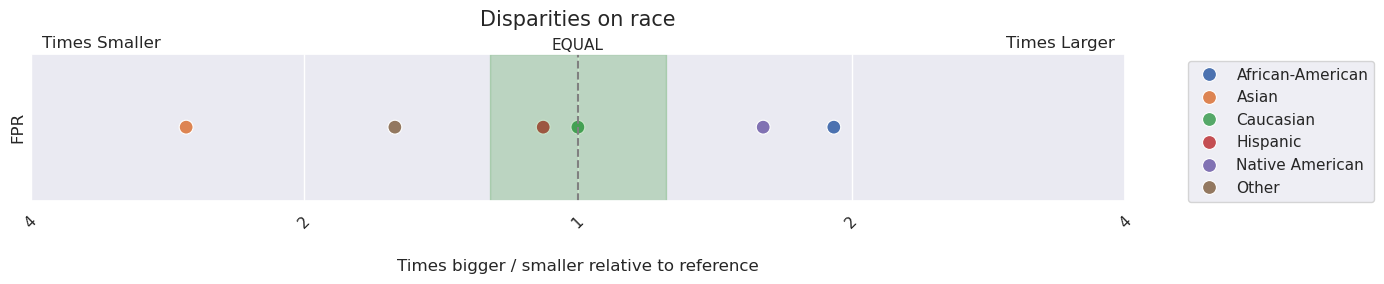

In [51]:
plot_disparity(bdf, 'race', 'Caucasian', 'fpr','Disparities on race', 1.25)

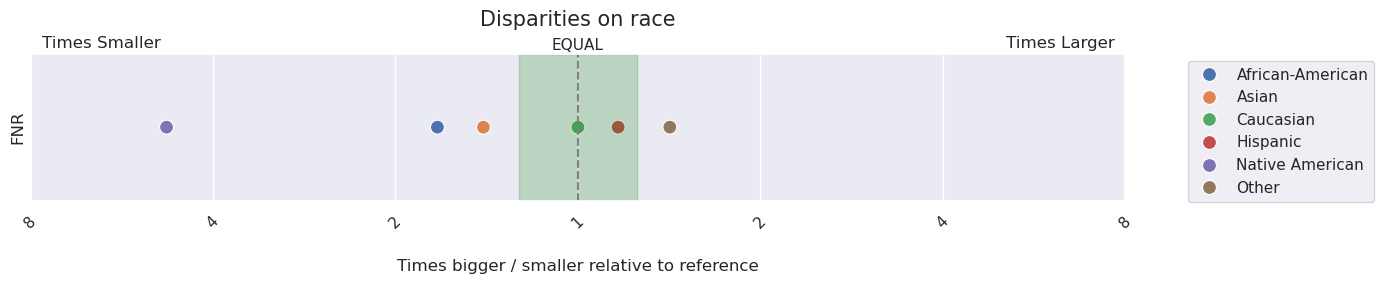

In [52]:
plot_disparity(bdf, 'race', 'Caucasian', 'fnr','Disparities on race', 1.25)

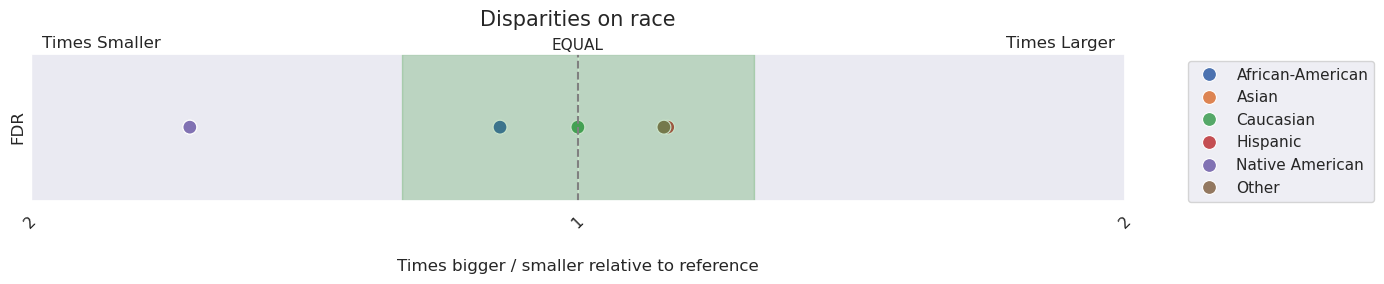

In [53]:
plot_disparity(bdf, 'race', 'Caucasian', 'fdr','Disparities on race', 1.25)

Below we see disparity values for Sex and Age.

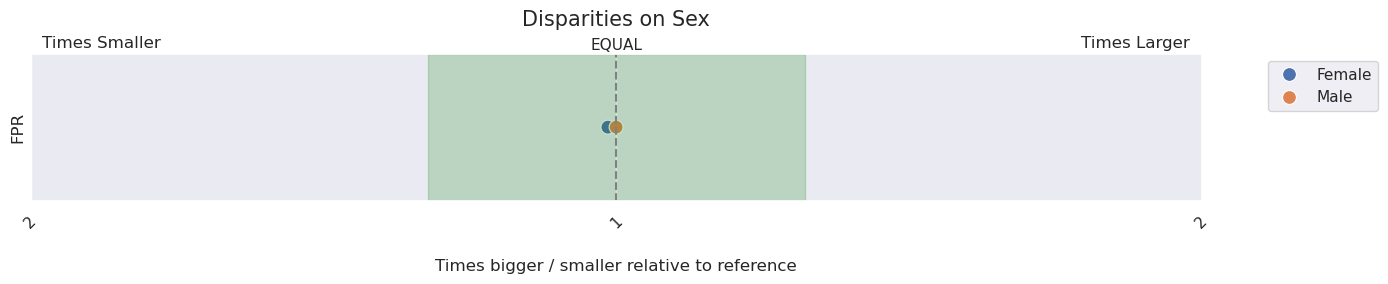

In [54]:
plot_disparity(bdf, 'sex', 'Male', 'fpr','Disparities on Sex', 1.25)

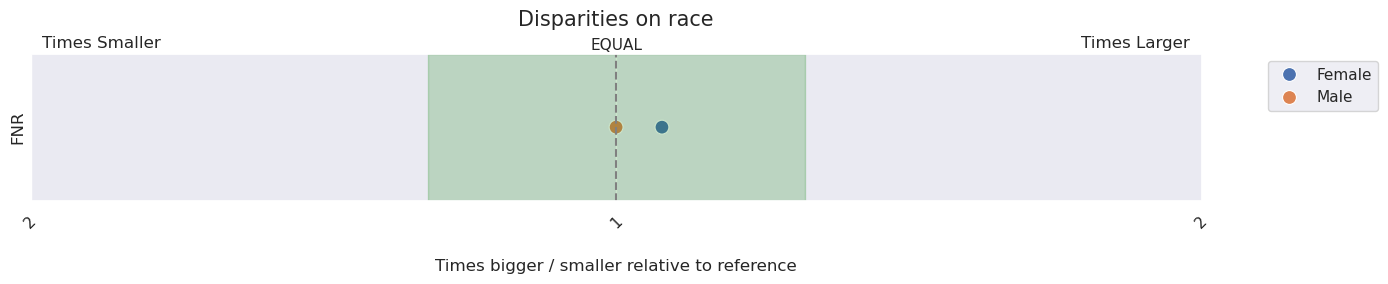

In [55]:
plot_disparity(bdf, 'sex', 'Male', 'fnr','Disparities on race', 1.25)

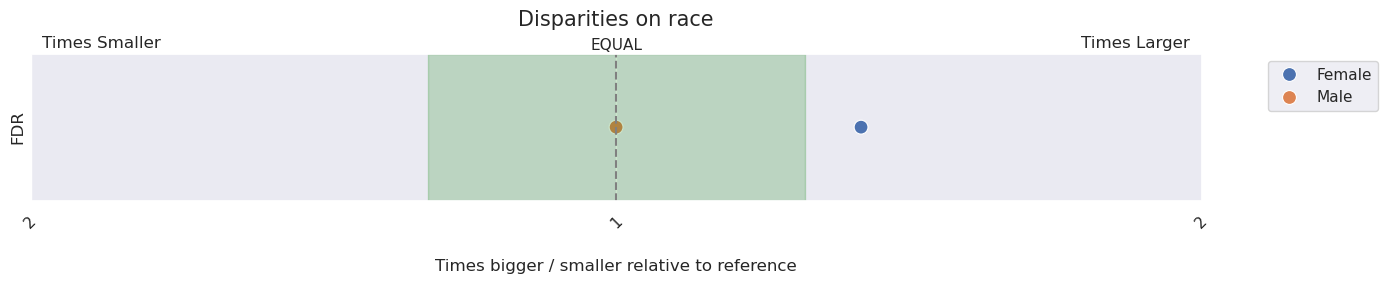

In [56]:
plot_disparity(bdf, 'sex', 'Male', 'fdr','Disparities on race', 1.25)

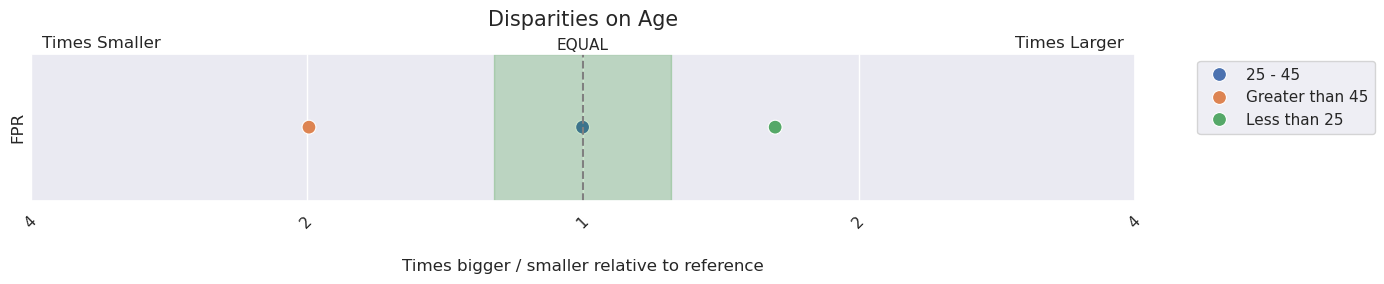

In [57]:
plot_disparity(bdf, 'age_cat', '25 - 45', 'fpr','Disparities on Age', 1.25)

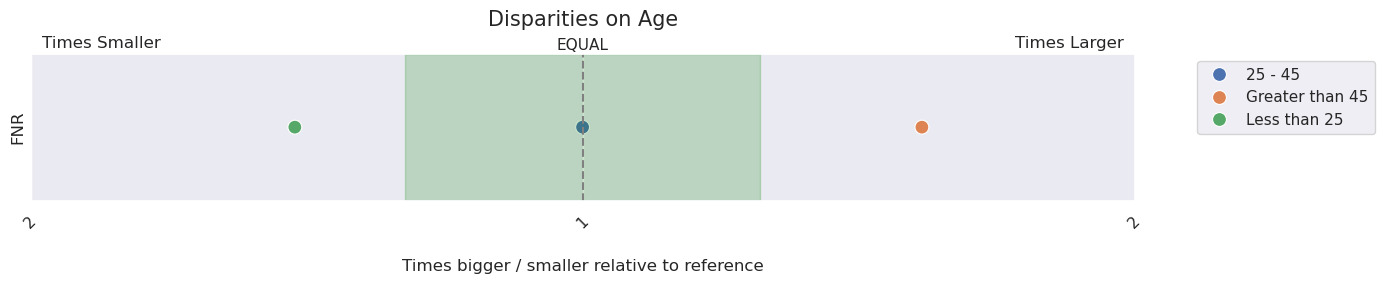

In [58]:
plot_disparity(bdf, 'age_cat', '25 - 45', 'fnr','Disparities on Age', 1.25)

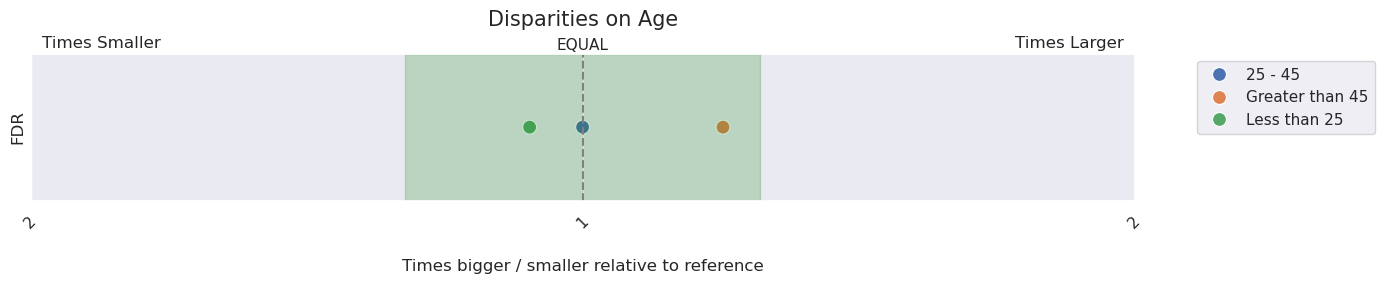

In [59]:
plot_disparity(bdf, 'age_cat', '25 - 45', 'fdr','Disparities on Age', 1.25)

**Let us see below how to visualize disparities and how to interpret parities**

In [60]:
b=Bias(df)
g=Group(df)
f = Fairness()
fdf = f.get_group_value_fairness(bdf)

In [61]:
parity_detrminations = f.list_parities(fdf)
absolute_metrics = g.list_absolute_metrics(fdf)
fdf[['attribute_name', 'attribute_value'] + absolute_metrics + b.list_disparities(fdf) + parity_detrminations].style

,attribute_name,attribute_value,fdr_disparity,fnr_disparity,for_disparity,fpr_disparity,npv_disparity,ppr_disparity,pprev_disparity,precision_disparity,tnr_disparity,tpr_disparity,FOR Parity,FDR Parity,NPV Parity,FPR Parity,TNR Parity,Supervised Fairness,TPR Parity,Unsupervised Fairness,Equalized Odds,TypeI Parity,Statistical Parity,FNR Parity,Impact Parity,TypeII Parity,Precision Parity
0,race,African-American,0.906085,0.586416,1.213154,1.912093,0.913728,2.545667,1.690224,1.064904,0.720526,1.377549,True,True,True,False,False,False,False,False,False,False,False,False,False,False,True
1,race,Asian,0.611748,0.698482,0.433839,0.370749,1.229148,0.009368,0.718384,1.268317,1.192808,1.275248,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False
2,race,Caucasian,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
3,race,Hispanic,1.120464,1.165140,1.001616,0.915887,0.999346,0.222482,0.857099,0.916748,1.025773,0.849249,True,True,True,True,True,True,True,False,True,True,False,True,True,True,True
4,race,Native American,0.611748,0.209544,0.578453,1.598854,1.170618,0.014052,1.915691,1.268317,0.816506,1.721584,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False
5,race,Other,1.115085,1.417970,1.048203,0.629057,0.980490,0.092506,0.602147,0.920466,1.113660,0.618447,True,True,True,False,True,False,False,False,False,False,False,False,False,False,True
6,sex,Female,1.336425,1.055810,0.734738,0.990343,1.130710,0.216801,0.904348,0.806925,1.004633,0.967101,False,False,True,True,True,False,True,False,True,False,False,True,True,False,True
7,sex,Male,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
8,age_cat,25 - 45,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
9,age_cat,Greater than 45,1.192804,1.531238,0.746232,0.503031,1.121136,0.204782,0.533914,0.879232,1.248989,0.682963,False,True,True,False,True,False,False,False,False,False,False,False,False,False,True


By construction, the base reference groups (Caucasian for race, Male for gender, and 25-45 for age_cat) have supervised fairness (i.e., the disparity ratio is 1 for all metrics). In addition, only the Hispanic group exhibits also supervised fairness (pay attention to *for_disparity equals 1*).

It is worth noting that the African-Americans are roughly twice as likely to have false positives as Caucasian (1.91 versus 1.0) and 40 percent less likely to false negatives (0.58 versus 1.0). In real terms, 44.8% of African-Americans who did not recidivate were marked high or medium risk (with potential for associated penalties), compared with 23.4% of Caucasian non-reoffenders. This is unfair.

With the following table we see which pairs group-metric pass the parity test. For a group to pass the parity test its disparity to the reference group must be below the threshold for all attributes and the selected metrics.

In [62]:
gaf = f.get_group_attribute_fairness(fdf)
gaf

,model_id,score_threshold,attribute_name,Statistical Parity,Impact Parity,FDR Parity,FPR Parity,FOR Parity,FNR Parity,TPR Parity,TNR Parity,NPV Parity,Precision Parity,TypeI Parity,TypeII Parity,Equalized Odds,Unsupervised Fairness,Supervised Fairness
0,0,binary 0/1,age_cat,False,False,True,False,False,False,False,False,True,True,False,False,False,False,False
1,0,binary 0/1,race,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,0,binary 0/1,sex,False,True,False,True,False,True,True,True,True,True,False,False,True,False,False


### **Exercise 5.a**

A court uses COMPAS to assist in parole decisions.
As you have seen, results from Aequitas' analysis show racial disparities in the calculated metrics.
The judge requests a specific recommendation based on quantitative evidence. Your task is to analyze group-level outcomes and make a justified decision on which metric to prioritize when setting a decision threshold.

Using the fdf table obtained from Aequitas extract the absolute values of FPR and FNR for groups African-American and Caucasian of the protected attribute race.

In [83]:
filtered = fdf[
    (fdf["attribute_name"] == "race") &
    (fdf["attribute_value"].isin(["African-American", "Caucasian"]))
]

display(filtered[['attribute_name','attribute_value','fnr','fpr']])

,attribute_name,attribute_value,fnr,fpr
0,race,African-American,0.279853,0.448468
2,race,Caucasian,0.477226,0.234543


The judge doesn't understand technical terms like FPR and FNR and wants a simple recommendation.

- **Explain in plain language what it means to be a false positive (FP) and a false negative (FN) in the context of COMPAS predicting recidivism.**  
`FP stands for Flase Positive and it menas that the system predicts that a person will commit again a crime, but in reality they do not.`.   
`FN stands for Flase Negative and it means that the system predicts that a person will not reiterate a crime, but they actually do.`.  
---
- **Overall, considering both FPR and FNR, which group experiences the greater unfairness in the current predictions?**  
`African-Americans are much more likely to be wrongly labeled as persons with an high tendence to reiterate crimes`  
- ---
- **Suppose you have to choose only one metric (FPR or FNR) to ensure parity across racial groups. Which one would you select and why?**  
`I would choose the False Positive Rate (FPR) because reducing it can help to decrease the risk of unjustice.`  
---
- **In the context of colon cancer prediction, what does it mean to be a false positive (FP) and a false negative (FN)? In this case, what would be the most critical metric?**  
`FP : The model predicts cancer, but the patient does not have cancer.`  
`FN :The model predicts no cancer, but the patient actually has cancer`  
`False Negative Rate is the most critical metric because missing a cancer diagnosis can lead to  serious damage or even the death of a patient.` 


We have seen that some groups are more vulnerable than others. It is possible that combining these attributes may reveal new inequities that are not detected when each variable is considered separately.
- Create a new column that combines the sex and age variables.
- Perform an Aequitas audit using this new column as the protected attribute.
- For 'fpr', 'fnr' and 'fdr' print the disparities and reflect: do new inequities appear within these combined groups? (Use summary_plot and disparity_plot)  
Yes —  Analysis reveals more disparities compared to analyzing sex or age separately.  
When combining sex and age_cat, some specific subgroups:  
Show larger deviations from the fairness threshold (1.25)  
Fall outside the acceptable fairness band  
Experience stronger imbalance in FPR, FNR, or FDR  
These disparities were less visible when examining sex or age alone.
Down below the results :
### Intersectional Disparities (sex_age)

| attribute_value            | fpr   | fnr   | fdr   | fpr_disparity | fnr_disparity | fdr_disparity |
|----------------------------|-------|-------|-------|---------------|---------------|---------------|
| Female_25 - 45             | 0.294 | 0.408 | 0.438 | 1.000         | 1.000         | 1.000         |
| Female_Greater than 45     | 0.153 | 0.662 | 0.593 | 0.520         | 1.624         | 1.354         |
| Female_Less than 25        | 0.617 | 0.177 | 0.537 | 2.098         | 0.434         | 1.227         |
| Male_25 - 45               | 0.345 | 0.367 | 0.374 | 1.173         | 0.900         | 0.854         |
| Male_Greater than 45       | 0.172 | 0.557 | 0.436 | 0.585         | 1.367         | 0.995         |
| Male_Less than 25          | 0.514 | 0.273 | 0.316 | 1.749         | 0.670         | 0.721   

The largest disparity appears in FPR for Female_Less than 25 (2.098) and Male_Less than 25 (1.749), indicating substantial inequity in false positive classifications for younger individuals.   
FNR disparities are also elevated for Female_Greater than 45 (1.624) and Male_Greater than 45 (1.367).  
This confirms that intersectional analysis reveals stronger disparities than analyzing sex or age separately.        |

['Male_Greater than 45' 'Male_25 - 45' 'Male_Less than 25'
 'Female_25 - 45' 'Female_Greater than 45' 'Female_Less than 25']

=== FPR, FNR, FDR and Their Disparities (sex_age) ===



,attribute_value,fpr,fnr,fdr,fpr_disparity,fnr_disparity,fdr_disparity
0,Female_25 - 45,0.294,0.408,0.438,1.000,1.000,1.000
1,Female_Greater than 45,0.153,0.662,0.593,0.520,1.624,1.354
2,Female_Less than 25,0.617,0.177,0.537,2.098,0.434,1.227
3,Male_25 - 45,0.345,0.367,0.374,1.173,0.900,0.854
4,Male_Greater than 45,0.172,0.557,0.436,0.585,1.367,0.995
5,Male_Less than 25,0.514,0.273,0.316,1.749,0.670,0.721



=== Groups Exceeding Fairness Threshold (1.25) ===


FPR_DISPARITY:
       attribute_value  fpr_disparity
2  Female_Less than 25          2.098
5    Male_Less than 25          1.749

FNR_DISPARITY:
          attribute_value  fnr_disparity
1  Female_Greater than 45          1.624
4    Male_Greater than 45          1.367

FDR_DISPARITY:
          attribute_value  fdr_disparity
1  Female_Greater than 45          1.354


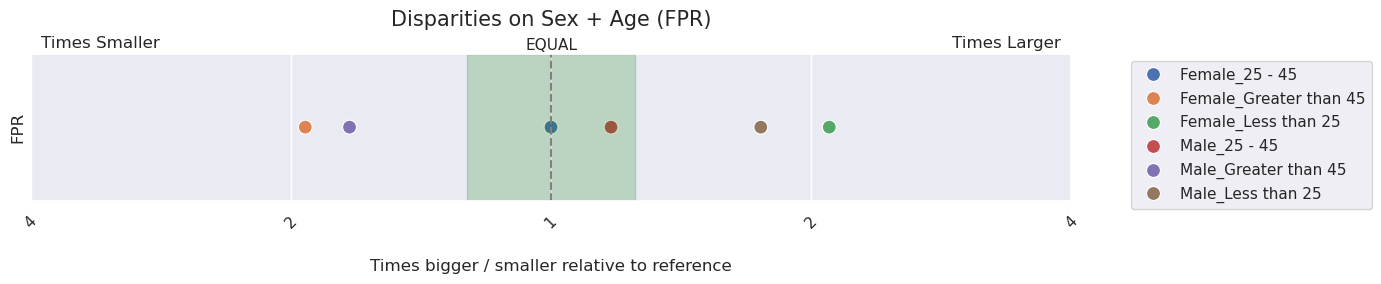

<Figure size 1150x650 with 0 Axes>

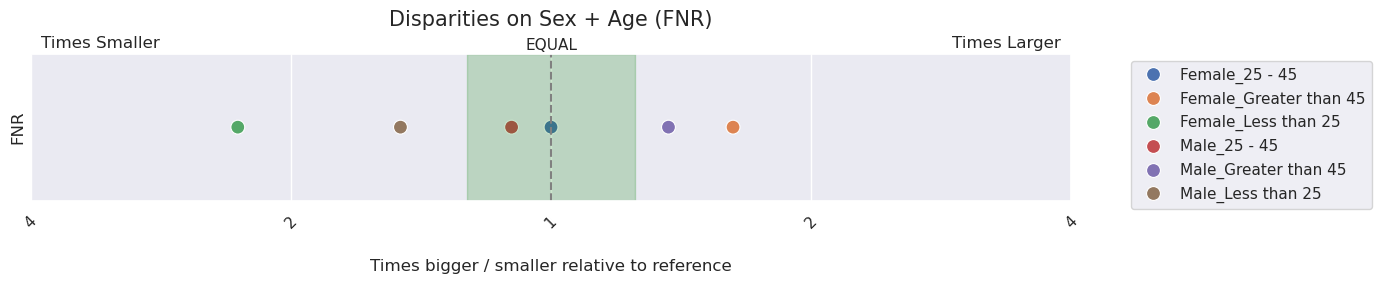

<Figure size 1150x650 with 0 Axes>

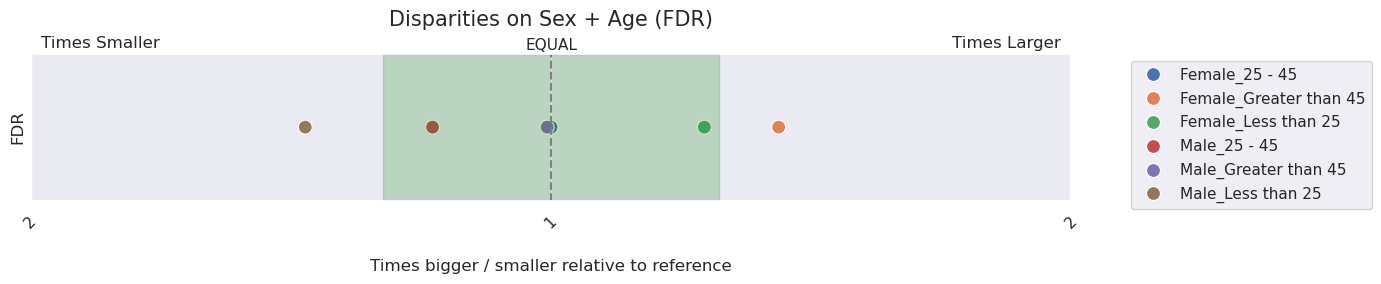

<Figure size 1150x650 with 0 Axes>

In [122]:
# Create combined protected attribute
# REVIEW
df = pd.read_csv("./testlib/COMPAS/compas_for_aequitas.csv")
# create new columns
df['sex_age'] = df['sex'] + "_" + df['age_cat']
df['sex_age'].unique()
df.head()

unique_sex_ages = df['sex_age'].unique()
print(f'{unique_sex_ages}')

# define groups
audit = Audit(df.drop(columns=["entity_id"]), label_column="label_value")
audit.audit()
audit.confusion_matrix

# we print results reounded with d decimal numbers
audit.metrics.round(3)
#compute disparities
auditd = Audit(
    df[['score', 'label_value', 'sex_age']],
    label_column="label_value",
    reference_groups={'sex_age': 'Female_25 - 45'}
)

auditd.audit(bias_args={
    "alpha": 0.05,
    "check_significance": True,
    "mask_significance": True
})

auditd.disparity_df.style

auditd.summary_plot(metrics=metrics, fairness_threshold=disparity_tolerance)

# check disparity
bdf=auditd.disparity_df
"""
print(f' fpr_disparity :\n {bdf.fpr_disparity}')
print(f' fnr_disparity :\n {bdf.fnr_disparity}')
print(f' fdr_disparity :\n {bdf.fdr_disparity}')
"""
# create dataframe for nice print
# set pandas display option
# Show all columns
pd.set_option('display.max_columns', None)
# Select relevant columns
results = bdf[['attribute_value',
               'fpr', 'fnr', 'fdr',
               'fpr_disparity',
               'fnr_disparity',
               'fdr_disparity']].round(3)

print("\n=== FPR, FNR, FDR and Their Disparities (sex_age) ===\n")
display(results)

print("\n=== Groups Exceeding Fairness Threshold (1.25) ===\n")

threshold = 1.25

for metric in ['fpr_disparity', 'fnr_disparity', 'fdr_disparity']:
    print(f"\n{metric.upper()}:")
    high = results[results[metric] > threshold]
    if len(high) > 0:
        print(high[['attribute_value', metric]])
    else:
        print("No groups exceed threshold.")

## PLOTS

bdf[['attribute_value', 'fpr', 'fnr', 'fdr',
     'fpr_disparity', 'fnr_disparity', 'fdr_disparity']]

plot_disparity(bdf, 'sex_age', 'Female_25 - 45', 'fpr',
               'Disparities on Sex + Age (FPR)', 1.25)

plt.savefig("Female_25-45_FPR.png", bbox_inches="tight", dpi=300)

plot_disparity(bdf, 'sex_age', 'Female_25 - 45', 'fnr',
               'Disparities on Sex + Age (FNR)', 1.25)

plt.savefig("Female_25-45_FNR.png", bbox_inches="tight", dpi=300)

plot_disparity(bdf, 'sex_age', 'Female_25 - 45', 'fdr',
               'Disparities on Sex + Age (FDR)', 1.25)
plt.savefig("Female_25-45_FDR.png", bbox_inches="tight", dpi=300)

Answer the following questions:
-  **If we only had information about the sex attribute for 'fpr' and 'fnr', does the sex_age attribute add new nuances?**  
Yes, it clearly adds new nuances.  
The results show that disparities are not uniform across age categories.  
Female_Less than 25 has an extremely high FPR disparity (2.098).  
Male_Less than 25 also shows a high FPR disparity (1.749).  
While, Male_Greater than 45 has a much lower FPR disparity (0.585).  
So that we can state that the sex_age attribute clearly reveals patterns that would be hidden if we only analyzed sex.
 
- **What if we only had information about the age attribute?**  
If we analyzed only age_cat, we would compare:  
a) Less than 25  
b) 25–45  
c) Greater than 45  

But we would not see how age interacts differently for males and females.  

As an example:  
Younger females show very high FPR disparity (2.098).  
Younger males also show high disparity (1.749), but not identical.  
Older females show high FNR disparity (1.624).  

The impact of age is not identical across sexes.  
Using sex_age uncovers intersectional disparities that are not visible when age is considered alone.  

- **What can you observe for the 'fdr' metric? Are there any new disparities?**  
The largest disparity is 1.354 (Female_Greater than 45).  
Most other groups remain close to 1.  
Only one group clearly exceeds the fairness threshold (1.25).  
Compared to FPR and FNR, FDR disparities are les imbalanced,more contained and less estreme.
A new disparity appears in FDR for Female_Greater than 45


### **Exercise 5.b**

The adult dataset is used to predict whether income exceeds $50K/yr based on census data. Load the adult for aequitas dataset you can find in the folder ADULT in testlib.
- Use Aequitas to audit this new dataset and obtain the disparities for the sensitive attributes gender, work_cat and age_cat as we've seen before. (Metrics: 'fpr', 'fnr' and 'fdr' | disparity_tolerance =1.25). Summarise it all in a summary plot.
- What disparities can you observe?

** Note: Do not be alarmed by the RuntimeWarning message. It appears because the model is so inaccurate with some groups (such as women) that it has zero correct predictions. 
Without variety in the data for that group, the mathematical calculations become unstable. This is a warning about the model's bias, not an error in your code.

In [64]:
# Read data
df = pd.read_csv("./testlib/ADULT/adult_for_aequitas.csv")
display(df.head())

for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())

,score,label_value,gender,work_cat,age_cat
0,0,0,Male,Private,38-59
1,0,0,Male,Self employed,38-59
2,0,0,Male,Private,38-59
3,0,0,Female,Private,<38
4,0,0,Male,Private,38-59



Column: score
[0 1]

Column: label_value
[0 1]

Column: gender
['Male' 'Female']

Column: work_cat
['Private' 'Self employed' 'other']

Column: age_cat
['38-59' '<38' '>59' nan]


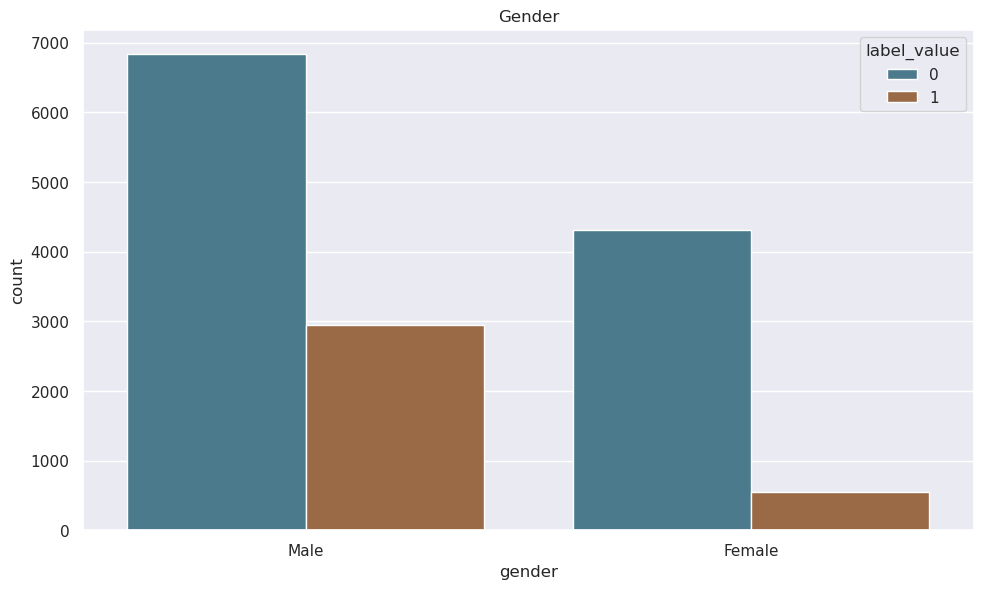

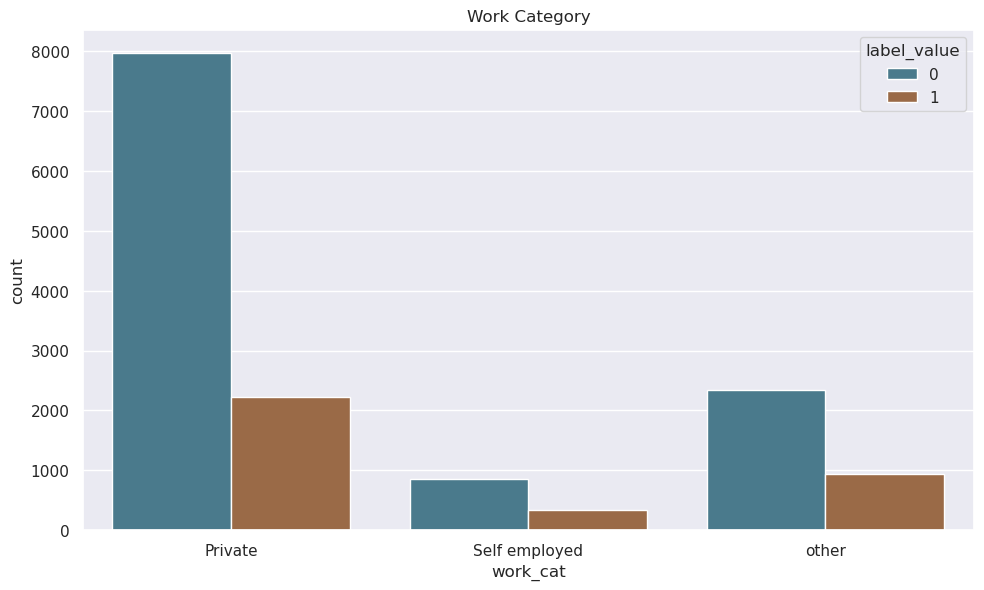

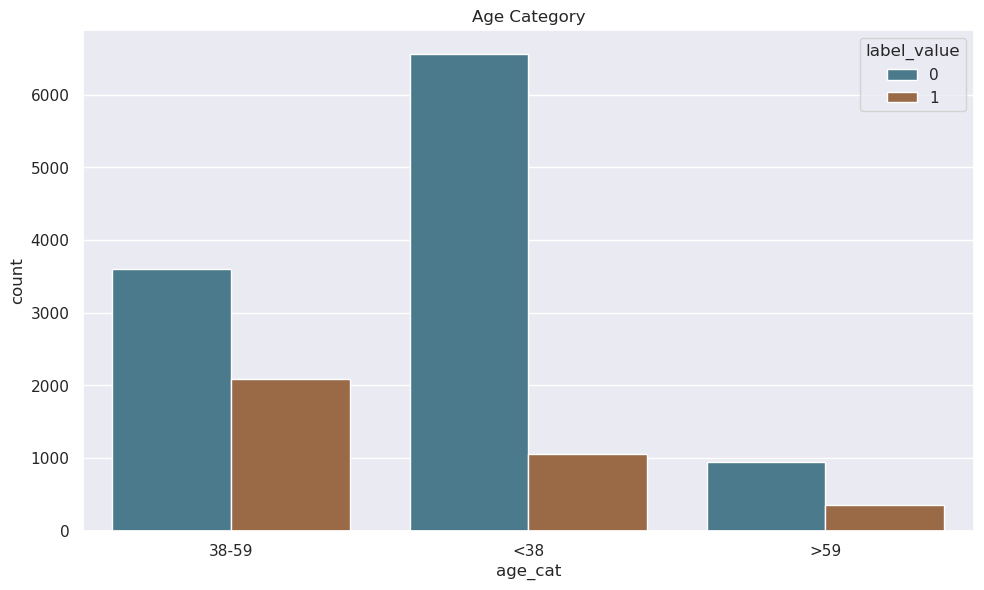

In [65]:
# Check reference group

# Plot 1: Gender
plt.figure()
sns.countplot(
    x="gender",
    hue="label_value",
    data=df[df.gender.isin(['Male', 'Female'])],
    palette=aq_palette
)
plt.title("Gender")
plt.show()

# Plot 2: Work Category
plt.figure()
sns.countplot(
    x="work_cat",
    hue="label_value",
    data=df[df.work_cat.isin(['Private', 'Self employed','other'])],
    palette=aq_palette
)
plt.title("Work Category")
plt.show()

# Plot 3: Age Category
plt.figure()
sns.countplot(
    x="age_cat",
    hue="label_value",
    data=df[df.age_cat.isin(['<38', '38-59','>59'])],
    palette=aq_palette
)
plt.title("Age Category")
plt.show()

In [66]:
auditd = Audit(df, label_column="label_value", reference_groups={'gender':'Male', 'work_cat':'Private', 'age_cat':'<38'})

auditd.audit(bias_args={
    "alpha": 0.05,
    "check_significance": True,
    "mask_significance": True
})

metrics = ['fpr','fnr','fdr']
disparity_tolerance = 1.25

auditd.summary_plot(metrics=metrics, fairness_threshold=disparity_tolerance)

/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment 

alt.VConcatChart(...)

We've seen above that combining attributes may reveal new inequities. Combine the sensitive attributes gender and age in a new attribute.
Audit the new dataset and get the summary plot with the same metrics and disparity tolerance as before.
- What can you observe for this new feature?
- Why is it not possible to calculate the relative disparity for some subgroups? What should be tuned to be able to calculate these diparities?
- If we were to tweak this metric, what possible implications would it have for the overall accuracy of the model?

**Note: Do not be concerned if you see NaN values in the FDR (False Discovery Rate) metric. This occurs when the model does not make any positive predictions for that group (pp column = 0). 
As there are no positive predictions, the mathematical calculation of the ratio cannot be performed. In such cases, consult the FPR column to understand the behaviour of the model.

In [67]:
df["gender_age"] = df["gender"] + "_" + df["age_cat"]
display(df.head())

,score,label_value,gender,work_cat,age_cat,gender_age
0,0,0,Male,Private,38-59,Male_38-59
1,0,0,Male,Self employed,38-59,Male_38-59
2,0,0,Male,Private,38-59,Male_38-59
3,0,0,Female,Private,<38,Female_<38
4,0,0,Male,Private,38-59,Male_38-59


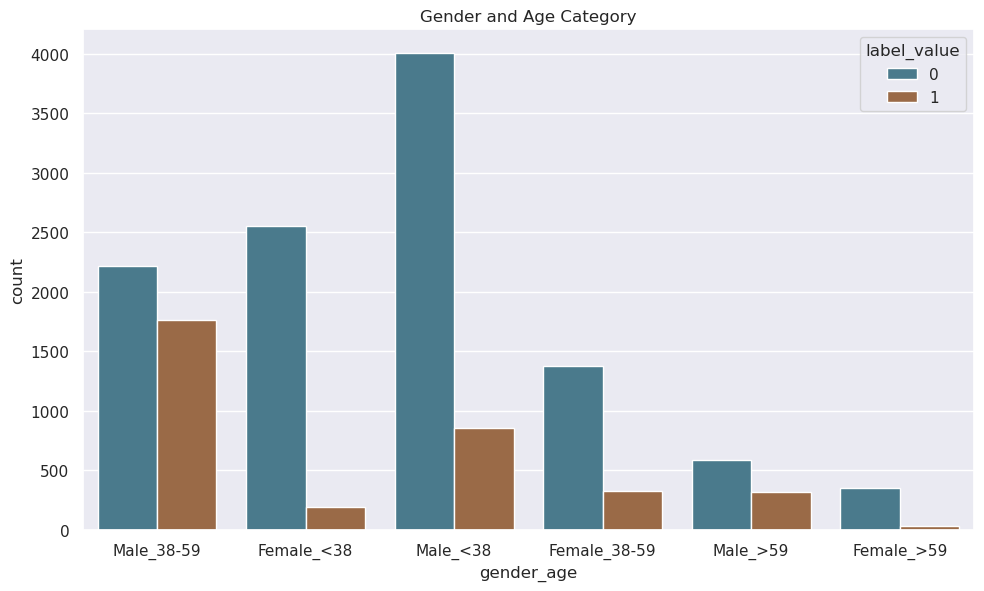

In [68]:
# Plot 4: Gender and Age Category
plt.figure()
sns.countplot(
    x="gender_age",
    hue="label_value",
    data=df[df.gender_age.isin(['Male_<38', 'Male_38-59','Male_>59', 'Female_<38', 'Female_38-59','Female_>59'])],
    palette=aq_palette
)
plt.title("Gender and Age Category")
plt.show()

In [69]:
auditd = Audit(df, label_column="label_value", reference_groups={'gender':'Male', 'work_cat':'Private', 'age_cat':'<38', 'gender_age':'Male_<38'})

auditd.audit(bias_args={
    "alpha": 0.05,
    "check_significance": True,
    "mask_significance": True
})

metrics = ['fpr','fnr','fdr']
disparity_tolerance = 1.25

auditd.summary_plot(metrics=metrics, fairness_threshold=disparity_tolerance)

/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/opt/conda/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment 

alt.VConcatChart(...)

### **Exercise 5.b Answers**

**What disparities can you observe?**

`The plot shows consistent disparities across all three attributes: Gender, Work Category, and Age Category.`

`For Predictive Equality (which is the False Positive Rate), all three attributes fail the parity test. This indicates that at least one group within each attribute has a False Positive Rate that differs from the reference group beyond the fairness threshold. Therefore, there is disparity in how frequently different groups are incorrectly predicted as positive.`

`For False Negative Rate (FNR), Gender passes the parity test, meaning the groups within Gender have similar FNR values relative to the reference. However, Work Category and Age Category both fail, indicating disparities in how often positive cases are incorrectly predicted as negative for different work categories and age groups.`

`For False Discovery Rate (FDR), all three attributes fail again. This means that the proportion of incorrect positive predictions differs significantly across groups within Gender, Work Category, and Age Category.`

`Overall, the main disparities are observed in Predictive Equality and FDR across all attributes, and additionally in FNR for Work Category. Gender appears more balanced only with respect to FNR, but still shows disparities for the other fairness metrics.`

**What can you observe for this new feature?**

`After combining gender and age into a single intersectional attribute (Gender_Age), the summary plot shows that this new feature fails the parity test for all three metrics: Predictive Equality, FNR, and FDR. This indicates stronger disparities at the intersectional level compared to evaluating gender and age separately. In particular, while gender alone previously passed for FNR, the combined Gender_Age attribute now fails for FNR. This reveals that some specific gender–age subgroups experience unequal error rates that were not visible when looking at gender or age independently. Therefore, combining attributes uncovers intersectional inequities that were hidden in the single-attribute analysis.`

**Why is it not possible to calculate the relative disparity for some subgroups? What should be tuned to be able to calculate these diparities?**

`The relative disparity cannot be calculated for some subgroups because their False Positive count (fp) or other required counts are zero. When a metric such as FPR or FDR equals zero for a subgroup, the disparity calculation involves division by zero or undefined ratios relative to the reference group. As a result, Aequitas cannot compute the relative disparity and excludes those groups from the visualization.`

`To enable the calculation of disparities, one would need to adjust aspects such as the decision threshold of the classifier (which affects the number of predicted positives and negatives) or modify how groups are defined to avoid extremely small subgroups. Increasing the sample size of underrepresented intersectional groups could also help. In short, the issue stems from very small or perfectly classified groups that produce zero denominators in the metric calculations.`

**If we were to tweak this metric, what possible implications would it have for the overall accuracy of the model?**

`If we adjust the model to reduce disparities in metrics like FPR, FNR, or FDR across intersectional groups (for example by changing the decision threshold or applying fairness constraints), this may affect the overall predictive performance. In many cases, improving fairness for disadvantaged subgroups requires accepting a trade-off, such as increasing errors in previously advantaged groups or slightly reducing global accuracy. Therefore, reducing disparity across Gender_Age groups could lead to a decrease in overall accuracy, since the model may need to rebalance its predictions to achieve more equal error rates across intersectional sub-populations.`